# Лабораторная работа №1
## Анализ и прогнозирование временных рядов на примере розничных продаж

Выполнил студент группы М8О-203СВ-25 

Чуркин Алексей Андреевич

**Датасет:** `retail_sales_mock_data.csv` , содержит временной ряд розничных продаж.


## Установка зависимостей (при отсутствии раскомментить)

In [86]:
# !pip install -q pandas numpy matplotlib seaborn statsmodels scipy scikit-learn PyWavelets

## 1. Импорты и загрузка данных

In [87]:
# Не знаю, насколько подробно нужно пояснять, но постараюсь максимально подробно)
# Числа и таблицы
import numpy as np
import pandas as pd
# Для графиков
import matplotlib.pyplot as plt
import seaborn as sns
# Будем генерировать комбинации порядков
import itertools
# Для расчетов
from scipy import stats
from scipy.fft import fft, fftfreq
from scipy.signal import detrend
from scipy.stats import shapiro
import pywt

# Для анализа временных рядлов
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, r2_score

# Настраиваем графики
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_style('whitegrid')

# Загружаем данные для лабы и делаем месячную частоту
df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'], index_col='Date')
df = df.asfreq('MS')
df.index.name = 'Date'
print(df.info())
df.head()


<class 'pandas.DataFrame'>
DatetimeIndex: 48 entries, 2020-01-01 to 2023-12-01
Freq: MS
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   SalesAmount   48 non-null     int64
 1   Promotion     48 non-null     int64
 2   HolidayMonth  48 non-null     int64
dtypes: int64(3)
memory usage: 1.5 KB
None


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Видим таблицу из 48 строк (не считая названия столбцов), каждая строка это новый месяц с 2020 по 2023 годы.

---
# 2.1. Разведочный анализ данных (EDA)


### 2.1.1. Описательная статистика и общий график

        SalesAmount  Promotion  HolidayMonth
count     48.000000  48.000000     48.000000
mean   11768.541667   0.125000      0.083333
std     2257.544863   0.334219      0.279310
min     7783.000000   0.000000      0.000000
25%    10219.750000   0.000000      0.000000
50%    11851.000000   0.000000      0.000000
75%    13014.000000   0.000000      0.000000
max    17996.000000   1.000000      1.000000


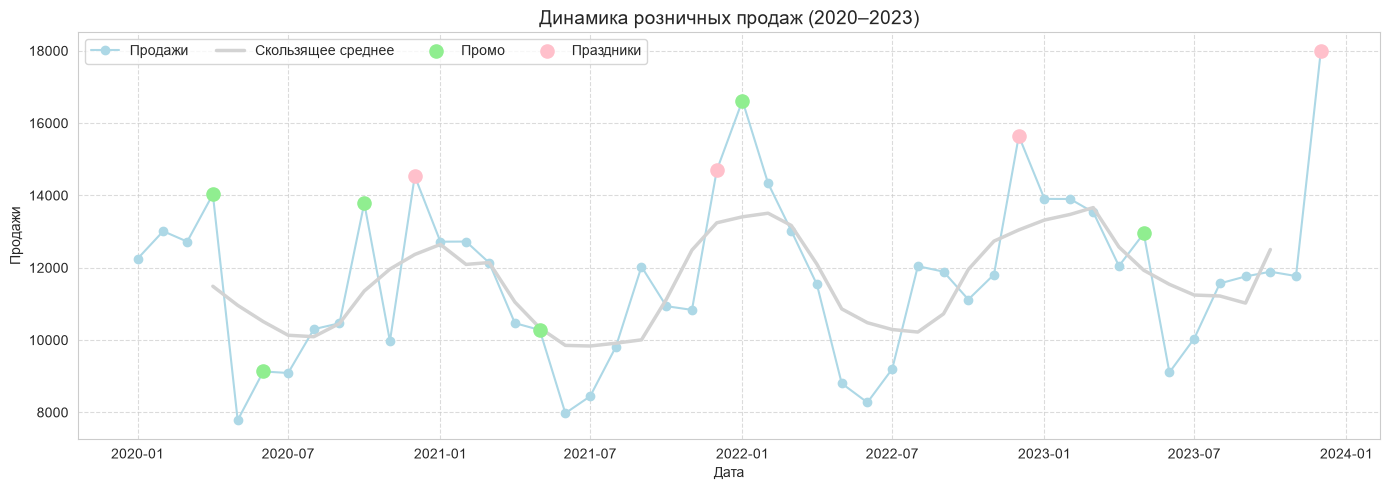

In [88]:
# Смотрим базовую статистику
print(df.describe())

# Создаем график
fig, ax = plt.subplots(figsize=(14, 5))
# Продажи
ax.plot(df.index, df['SalesAmount'], marker='o', color='lightblue', label='Продажи')
# Скользящее среднее за 6 месяцев
ax.plot(df.index, df['SalesAmount'].rolling(6, center=True).mean(),
        color='lightgray', linewidth=2.5, label='Скользящее среднее')
# Месяцы с промо
ax.scatter(df.index[df['Promotion'] == 1],
           df['SalesAmount'][df['Promotion'] == 1],
           color='lightgreen', s=90, zorder=3, label='Промо')
# Месяцы с праздниками
ax.scatter(df.index[df['HolidayMonth'] == 1],
           df['SalesAmount'][df['HolidayMonth'] == 1],
           color='pink', marker='o', s=90, zorder=3, label='Праздники')

ax.set_title('Динамика розничных продаж (2020–2023)', fontsize=14)
ax.set_xlabel('Дата'); ax.set_ylabel('Продажи')
ax.grid(True, alpha=0.7, linestyle='--')
ax.legend(ncol=4)

plt.tight_layout(); plt.show()

Можно заметить, что ряд имеет годовой сезонный паттерн (пики в декабре, минимумы в мае–июне) и слабый восходящий тренд. В мае 2020 и мае 2022 жесткие провалы


### 2.1.2. Распределение, boxplot по месяцам, rolling-статистики, ACF/PACF

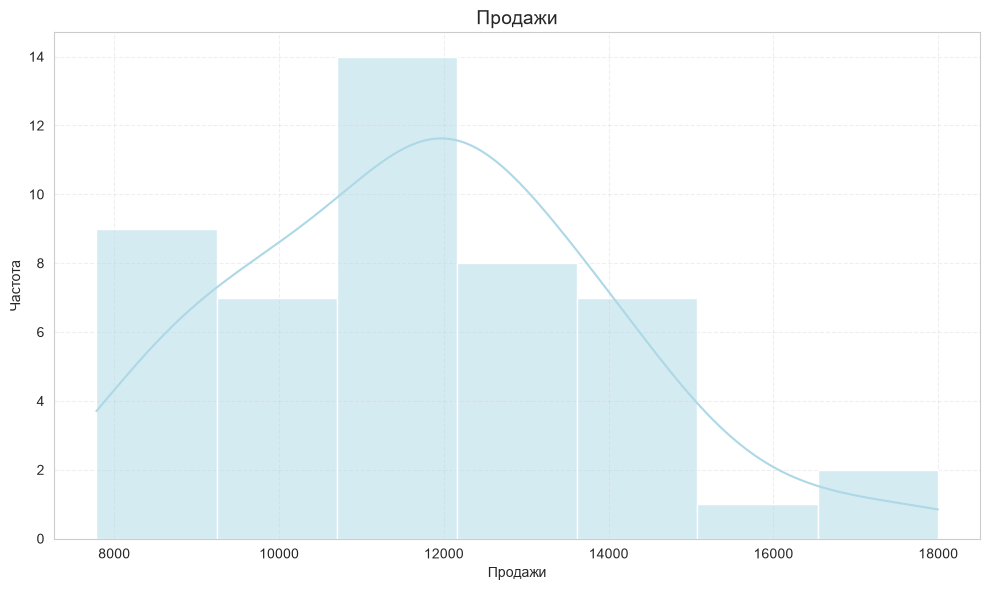

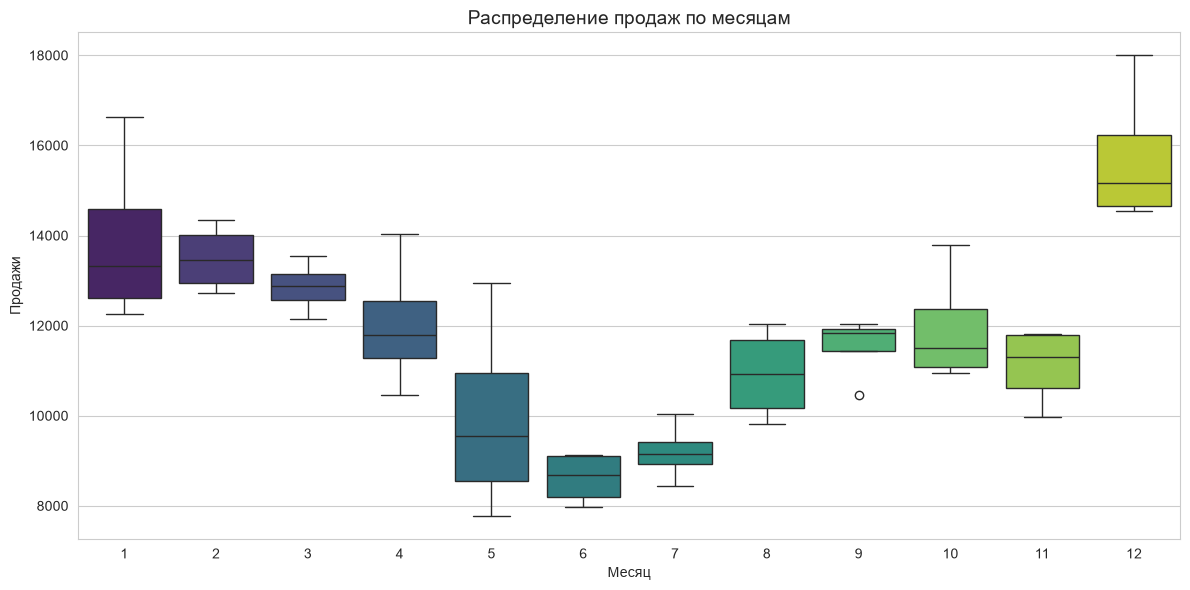

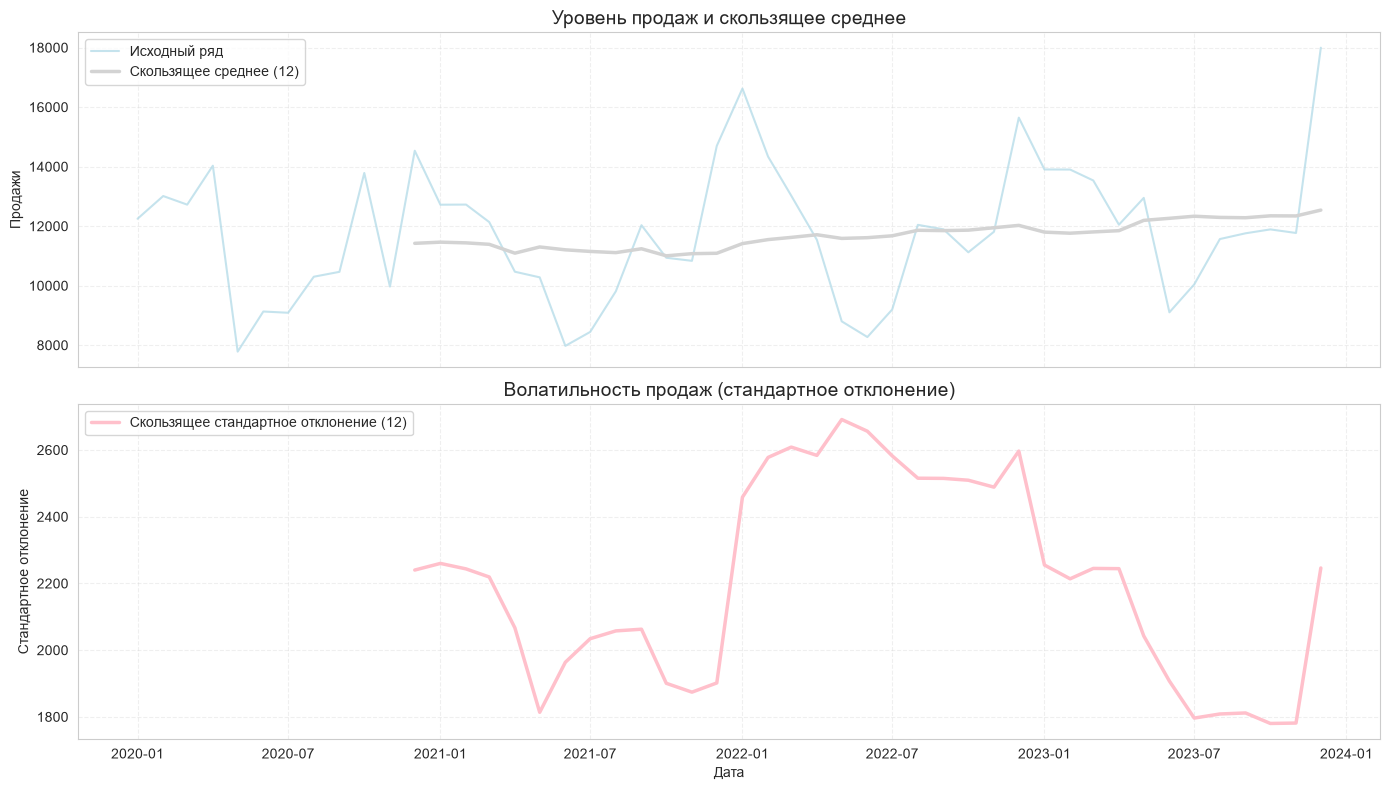

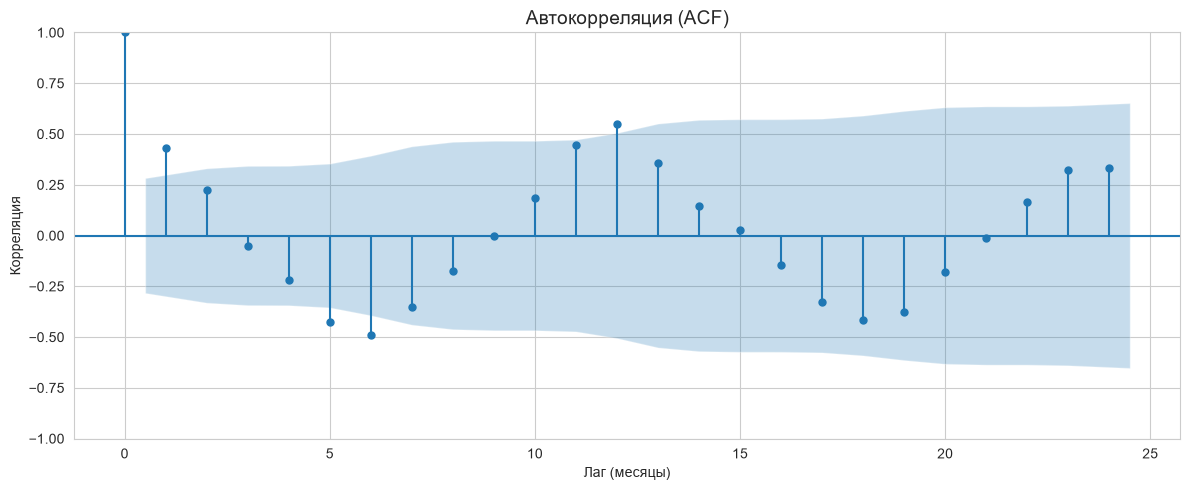

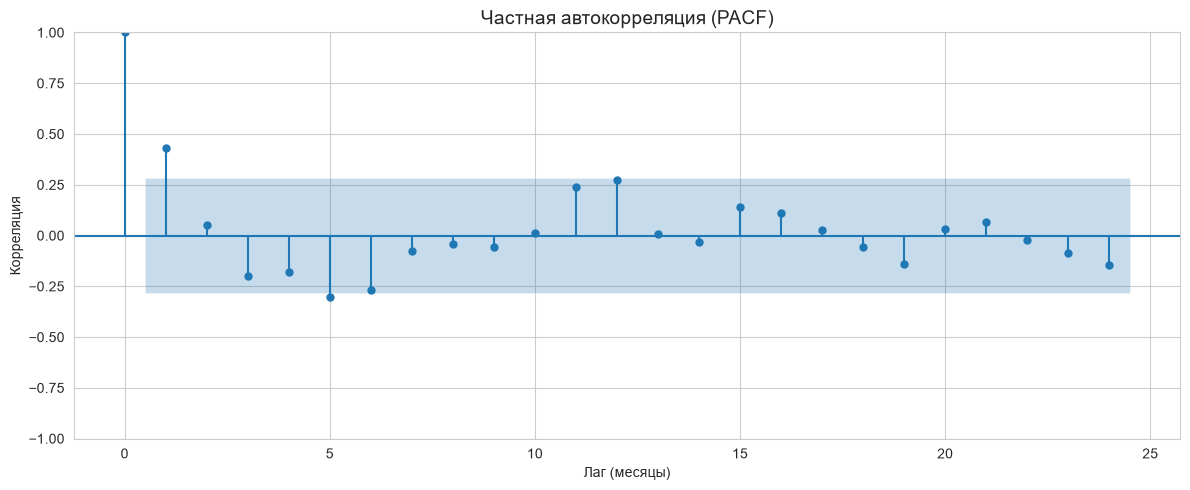

In [89]:
# Продажи
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df['SalesAmount'], kde=True, ax=ax, color='lightblue')
ax.set_title('Продажи', fontsize=14)
ax.set_xlabel('Продажи'); ax.set_ylabel('Частота')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout(); plt.show()

# Боксплот продаж по месяцам
# Копируем df и разбиваем данные по категориям
df_temp = df.copy()
df_temp['Month'] = df_temp.index.month
fig, ax = plt.subplots(figsize=(12, 6))
# Боксплот покажет медиану, квартили и выбросы для каждого месяца
sns.boxplot(x='Month', y='SalesAmount', data=df_temp, ax=ax, palette='viridis')
ax.set_title('Распределение продаж по месяцам', fontsize=14)
ax.set_xlabel('Месяц'); ax.set_ylabel('Продажи')
plt.tight_layout(); plt.show()

# Скользящие статистики за 12 месяцев
# уровень
roll_mean = df['SalesAmount'].rolling(12).mean()
# волатильность
roll_std  = df['SalesAmount'].rolling(12).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Сверху уровень продаж и скользящее среднее
axes[0].plot(df.index, df['SalesAmount'], label='Исходный ряд',
             color='lightblue', alpha=0.7)
axes[0].plot(df.index, roll_mean, label='Скользящее среднее (12)',
             color='lightgray', linewidth=2.5)
axes[0].set_title('Уровень продаж и скользящее среднее', fontsize=14)
axes[0].set_ylabel('Продажи')
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3, linestyle='--')

# Снизу волатильность. Кажется большим, так как ось Y от 1800 до 2600
axes[1].plot(df.index, roll_std, label='Скользящее стандартное отклонение (12)',
             color='pink', linewidth=2.5)
axes[1].set_title('Волатильность продаж (стандартное отклонение)', fontsize=14)
axes[1].set_xlabel('Дата'); axes[1].set_ylabel('Стандартное отклонение')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout(); plt.show()

# ACF, корреляция ряда с самим собой на разных лагах
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(df['SalesAmount'], lags=24, ax=ax)
ax.set_title('Автокорреляция (ACF)', fontsize=14)
ax.set_xlabel('Лаг (месяцы)'); ax.set_ylabel('Корреляция')
plt.tight_layout(); plt.show()

# PACF, чистая корреляция с лагом k при исключении влияния промежуточных лагов
fig, ax = plt.subplots(figsize=(12, 5))
plot_pacf(df['SalesAmount'], lags=24, ax=ax)
ax.set_title('Частная автокорреляция (PACF)', fontsize=14)
ax.set_xlabel('Лаг (месяцы)'); ax.set_ylabel('Корреляция')
plt.tight_layout(); plt.show()

### 2.1.3. Проверка стационарности (ADF-тест)

In [90]:
def adf_report(series, name=''):
    res = adfuller(series.dropna())
    print(f'ADF для {name}')
    print(f'ADF-статистика: {res[0]:.4f}')
    print(f'p-value:        {res[1]:.4f}')
    print(f'Крит. значения: {res[4]}')
    print('Ряд стационарен' if res[1] < 0.05 else 'Ряд НЕ стационарен')
    print()

adf_report(df['SalesAmount'], 'исходного ряда')
adf_report(df['SalesAmount'].diff().dropna(), 'первой разности')
adf_report(df['SalesAmount'].diff(12).dropna(), 'сезонной разности (12)')
adf_report(df['SalesAmount'].diff().diff(12).dropna(), 'd=1 + D=1')


ADF для исходного ряда
ADF-статистика: -4.5142
p-value:        0.0002
Крит. значения: {'1%': np.float64(-3.596635636000432), '5%': np.float64(-2.933297331821618), '10%': np.float64(-2.6049909750566895)}
Ряд стационарен

ADF для первой разности
ADF-статистика: -5.6296
p-value:        0.0000
Крит. значения: {'1%': np.float64(-3.626651907578875), '5%': np.float64(-2.9459512825788754), '10%': np.float64(-2.6116707716049383)}
Ряд стационарен

ADF для сезонной разности (12)
ADF-статистика: -3.6261
p-value:        0.0053
Крит. значения: {'1%': np.float64(-3.653519805908203), '5%': np.float64(-2.9572185644531253), '10%': np.float64(-2.6175881640625)}
Ряд стационарен

ADF для d=1 + D=1
ADF-статистика: -4.6697
p-value:        0.0001
Крит. значения: {'1%': np.float64(-3.6790595944893187), '5%': np.float64(-2.9678817237279103), '10%': np.float64(-2.6231583472057074)}
Ряд стационарен



In [91]:
# Сводная таблица тестов стационарности: ADF + KPSS
# ADF: Если p < 0.05, то ряд стационарен
# KPSS: Если p < 0.05, то ряд не стационарен
from statsmodels.tsa.stattools import kpss

def stationarity_summary(series, name):
    s = series.dropna()
    adf_p  = adfuller(s, autolag='AIC')[1]
    kpss_p = kpss(s, regression='c', nlags='auto')[1]

    if adf_p < 0.05 and kpss_p > 0.05:
        verdict = 'стационарен'
    elif adf_p > 0.05 and kpss_p < 0.05:
        verdict = 'нестационарен'
    else:
        verdict = 'выводы расходятся'

    return {
        'Ряд':            name,
        'ADF p-value':    round(adf_p, 4),
        'KPSS p-value':   round(kpss_p, 4),
        'Вердикт':        verdict,
    }

stationarity_table = pd.DataFrame([
    stationarity_summary(df['SalesAmount'],                  'Исходный ряд'),
    stationarity_summary(df['SalesAmount'].diff(),           'Первая разность'),
    stationarity_summary(df['SalesAmount'].diff(12),         'Сезонная разность (12)'),
    stationarity_summary(df['SalesAmount'].diff().diff(12),  'd = 1, D = 1'),
])
stationarity_table

C:\Users\Kweall\AppData\Local\Temp\ipykernel_11724\177947645.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\Kweall\AppData\Local\Temp\ipykernel_11724\177947645.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\Kweall\AppData\Local\Temp\ipykernel_11724\177947645.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_p = kpss(s, regression='c', nlags='auto')[1]
C:\Users\Kweall\AppData\Local\Temp\ipykernel_11724\177947645.py:9: InterpolationWarning: The test statistic is outside of the range of p-values a

,Ряд,ADF p-value,KPSS p-value,Вердикт
0,Исходный ряд,0.0002,0.1,стационарен
1,Первая разность,0.0000,0.1,стационарен
2,Сезонная разность (12),0.0053,0.1,стационарен
3,"d = 1, D = 1",0.0001,0.1,стационарен


Средний объем продаж около 11,8 тыс., коэффициент вариации около 19%. Декабрь 2023 по IQR попадает в зону потенциального выброса, но это сезонный пик, поэтому оставляем.

Совместное применение ADF и KPSS дает согласованный результат по всем проверенным вариантам ряда. Исходный ряд уже стационарен относительно среднего, то есть обычная разность `d = 1` строго не обязательна (с ней ряд тоже стационарен). А вот сезонную разность `D = 1` брать нужно, потому что сезонность сильная (см. ниже). Нужна ли `d = 1`, решим при подборе порядков в SARIMAX: переберем `d = 0` и `d = 1`.

ACF имеет заметный максимум на лаге 12 (на лаге 24 пик тоже есть, но он уже внутри доверительного интервала), а у PACF лаг 12 почти на границе значимости, зато хорошо виден лаг 1. Это подтверждает годовую сезонность и задает параметры модели: `s = 12`, `D = 1`, порядки `(p, q)` и `(P, Q)` выберем по AIC.

### 2.1.4. Классическая и STL-декомпозиция

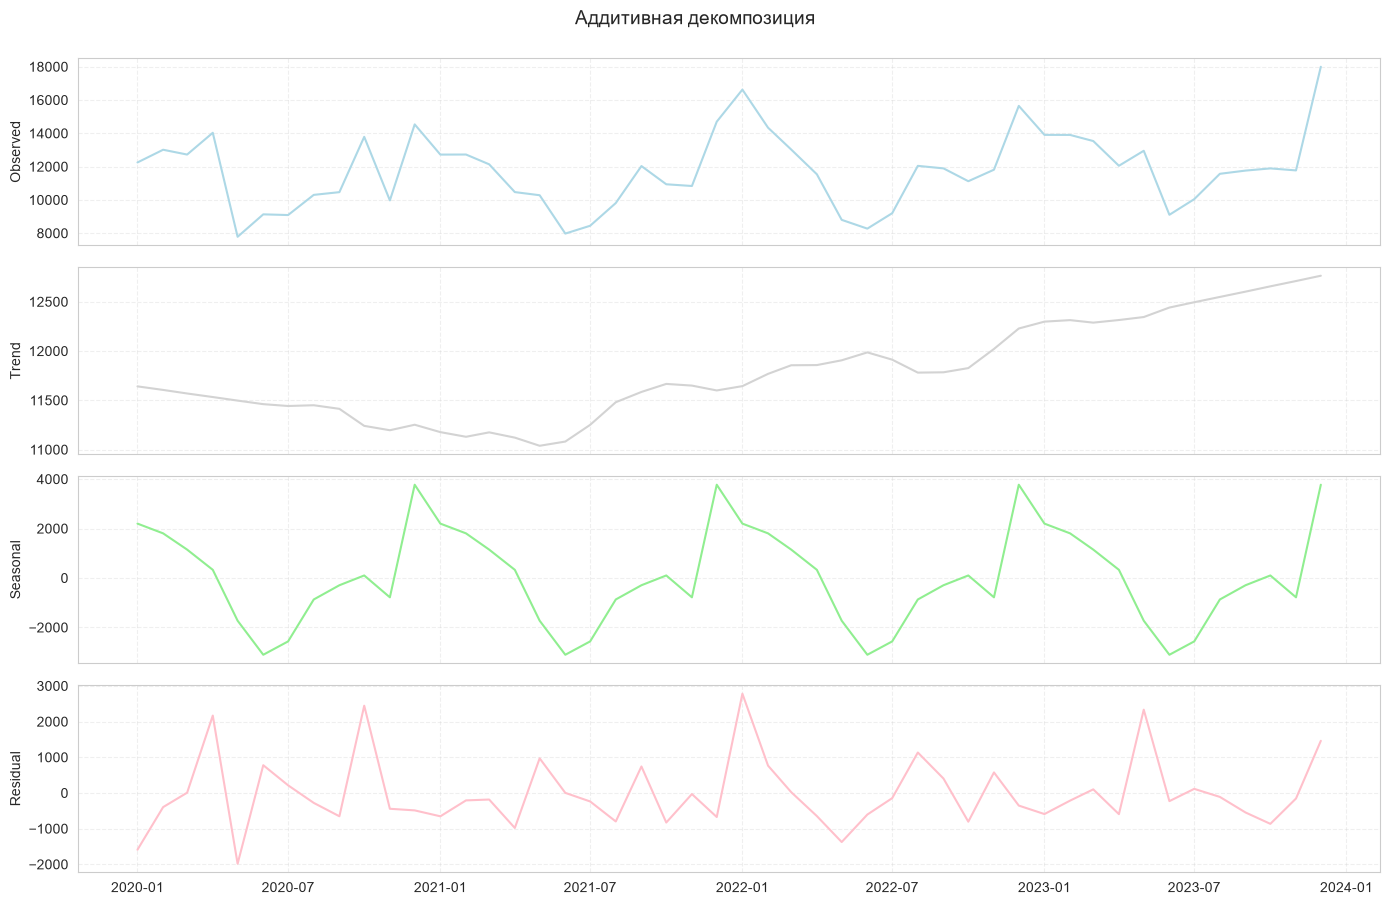

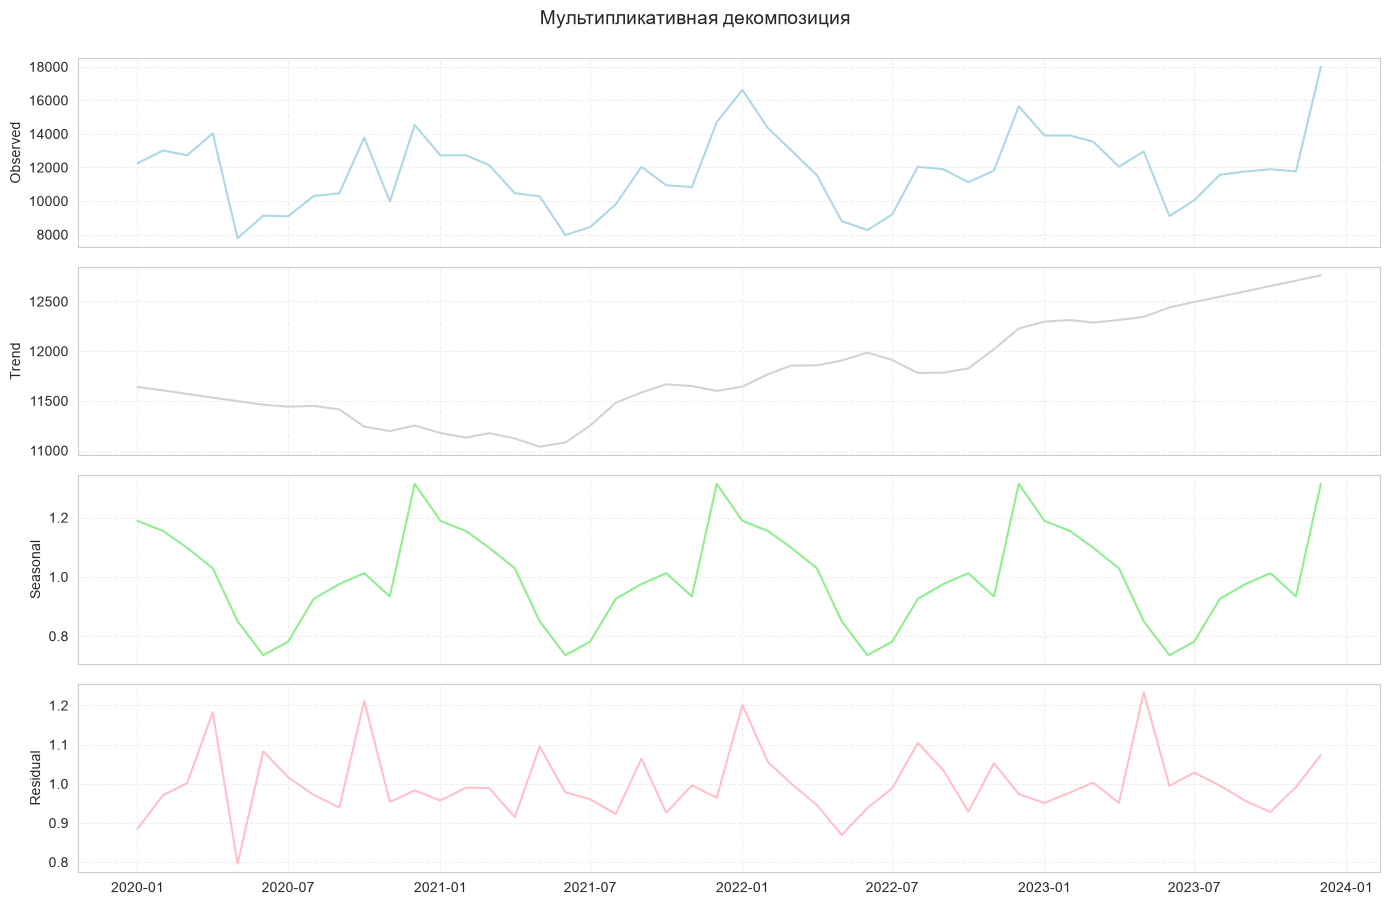

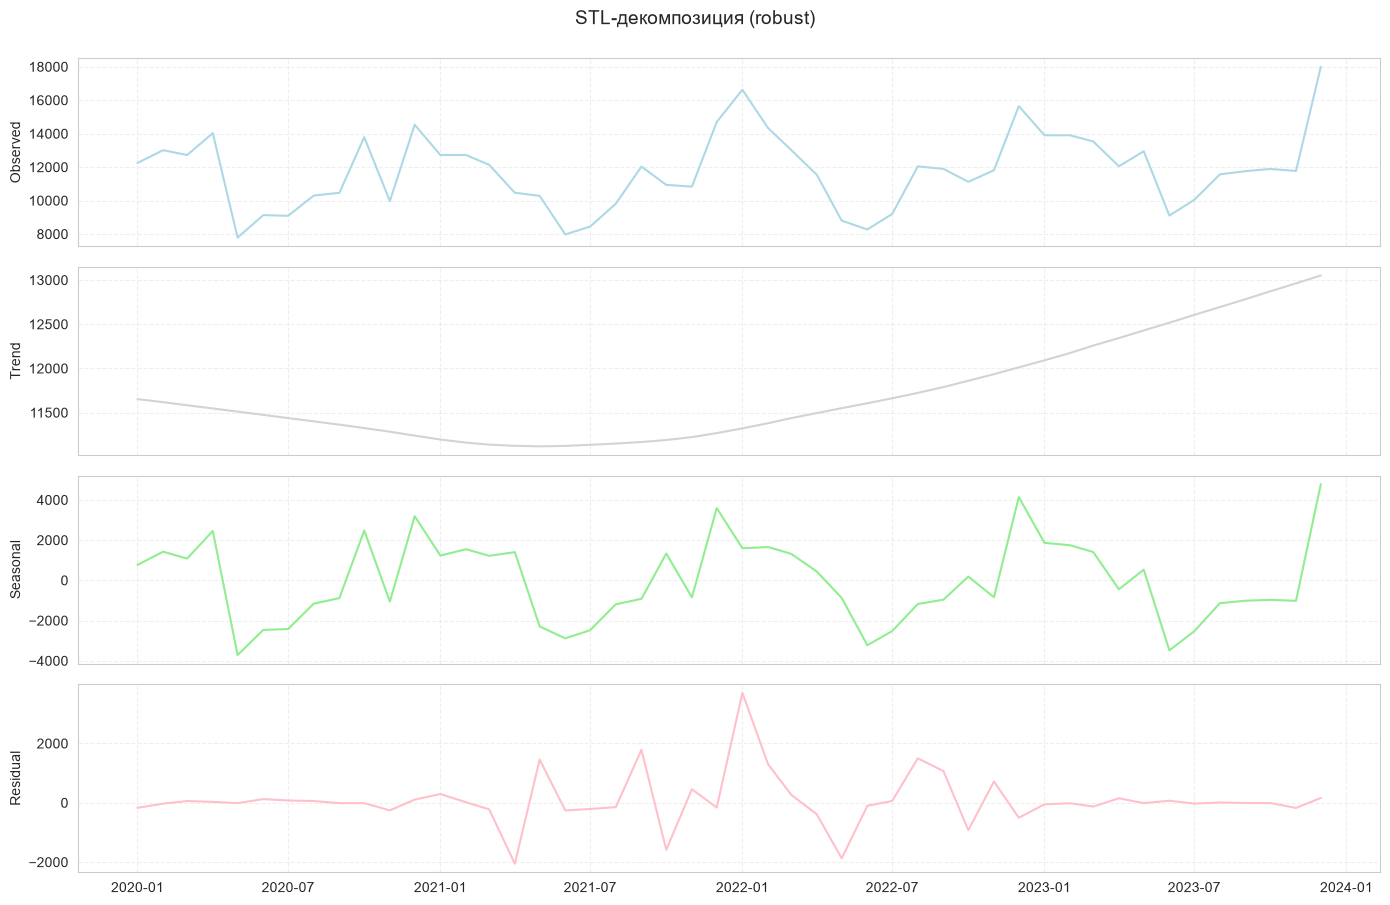

,Сила сезонности,Сила тренда
Метод,,
Аддитивная,0.792,0.202
Мультипликативная,0.790,0.201
STL,0.839,0.257


In [92]:
decomp_add = seasonal_decompose(df['SalesAmount'], model='additive', period=12, extrapolate_trend='freq')
decomp_mul = seasonal_decompose(df['SalesAmount'], model='multiplicative', period=12, extrapolate_trend='freq')
# robust=True снижает влияние выбросов, должно помочь с аномальной точкой в мае 2020
stl = STL(df['SalesAmount'], period=12, robust=True).fit()

def plot_decomposition(dec, title):
    fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
    axes[0].plot(dec.observed, color='lightblue');  axes[0].set_ylabel('Observed')
    axes[1].plot(dec.trend,    color='lightgray');  axes[1].set_ylabel('Trend')
    axes[2].plot(dec.seasonal, color='lightgreen'); axes[2].set_ylabel('Seasonal')
    axes[3].plot(dec.resid,    color='pink');       axes[3].set_ylabel('Residual')
    for a in axes:
        a.grid(True, alpha=0.3, linestyle='--')
    fig.suptitle(title, fontsize=14, y=1.00)
    plt.tight_layout(); plt.show()

plot_decomposition(decomp_add, 'Аддитивная декомпозиция')
plot_decomposition(decomp_mul, 'Мультипликативная декомпозиция')
plot_decomposition(stl,        'STL-декомпозиция (robust)')

# При единице дисперсия объясняется сезонностью
def strength(dec, multiplicative=False):
    if multiplicative:
        seas = (dec.seasonal - 1) * dec.trend
        res  = (dec.resid    - 1) * dec.trend
    else:
        seas = dec.seasonal
        res  = dec.resid

    s_season = max(0, 1 - np.nanvar(res) / np.nanvar(seas        + res))
    s_trend  = max(0, 1 - np.nanvar(res) / np.nanvar(dec.trend   + res))
    return s_season, s_trend

decomp_table = []
for name, dec, is_mult in [
    ('Аддитивная',        decomp_add, False),
    ('Мультипликативная', decomp_mul, True),
    ('STL',               stl,        False),
]:
    s_season, s_trend = strength(dec, is_mult)
    decomp_table.append({
        'Метод':           name,
        'Сила сезонности': round(s_season, 3),
        'Сила тренда':     round(s_trend,  3),
    })

pd.DataFrame(decomp_table).set_index('Метод')

Сила сезонности везже заметно превышает силу тренда, это подтверждает доминирование годовой сезонности. Различия между аддитивной и мультипликативной моделями минимальны, значит амплитуда сезонных колебаний слабо зависит от уровня ряда, и можно остановиться на аддитивной модели. STL с robust=True дает наибольшую силу сезонности и устойчив к аномалии мая 2020, поэтому на него можно ориентироваться при подборе SARIMAX.

### 2.1.5. Спектральный анализ (FFT)

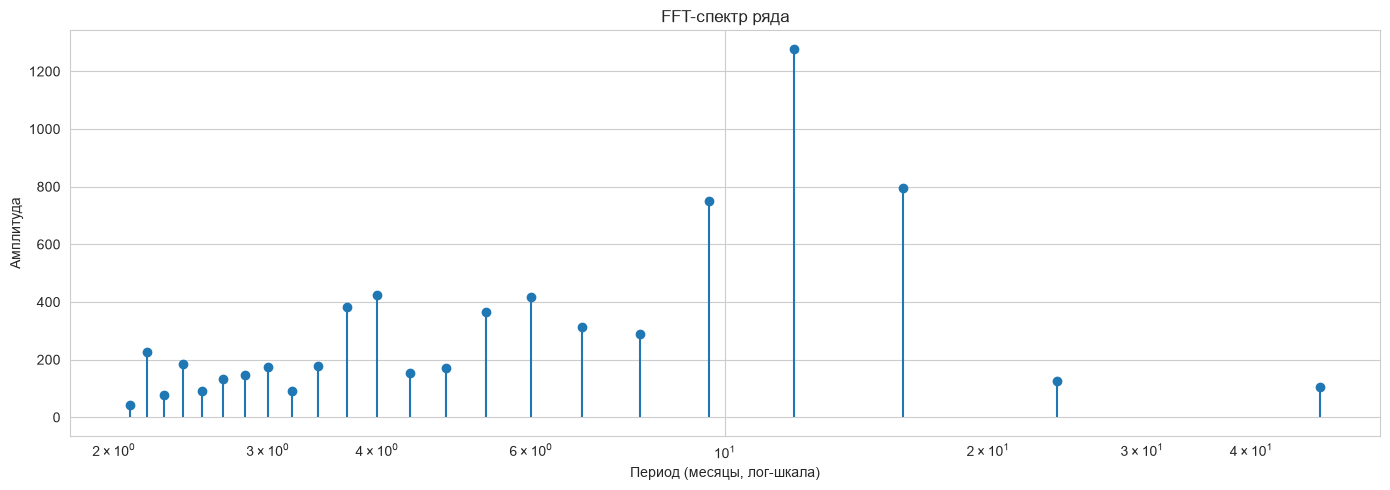

Топ 5 доминирующих периодов (в месяцах):
  Период ~ 12.00 мес., амплитуда = 1277.95
  Период ~ 16.00 мес., амплитуда = 795.02
  Период ~ 9.60 мес., амплитуда = 749.95
  Период ~ 4.00 мес., амплитуда = 424.04
  Период ~ 6.00 мес., амплитуда = 416.85


In [93]:
y = df['SalesAmount'].values
n = len(y)

# Убираем линейный тренд, чтобы убрать ложный низкочастотный пик в спектре
y_detrended = detrend(y)

# Окно Ханна ослабляет края ряда и снижает спектральную утечку
y_windowed = y_detrended * np.hanning(n)

# Приводим к нулевому среднему
y_centered = y_windowed - y_windowed.mean()

# Быстрое преобразование Фурье
yf = fft(y_centered)
xf = fftfreq(n, d=1)[:n // 2]
power = 2.0 / n * np.abs(yf[:n // 2])

# Периоды = 1 / частота; для нулевой частоты ставим inf, чтобы не делить на 0
periods = np.divide(1, xf, out=np.full_like(xf, np.inf), where=xf != 0)

# График спектра в периодах
fig, ax = plt.subplots(figsize=(14, 5))
ax.stem(periods[1:], power[1:], basefmt=' ')
ax.set_xscale('log')
ax.set_xlabel('Период (месяцы, лог-шкала)')
ax.set_ylabel('Амплитуда')
ax.set_title('FFT-спектр ряда')
plt.tight_layout(); plt.show()

# Топ 5 доминирующих периодов
top_idx = np.argsort(power[1:])[::-1][:5] + 1
print('Топ 5 доминирующих периодов (в месяцах):')
for i in top_idx:
    print(f'  Период ~ {periods[i]:.2f} мес., амплитуда = {power[i]:.2f}')

FFT после удаления тренда и применения окна Ханна показывает доминирующий пик на периоде 12 месяцев, значит годовая сезонность подтверждается. Периоды 6 и 4 месяца это гармоники 12-месячного периода: резкий декабрьский пик по форме не синусоида, поэтому в спектре появляются дополнительные частоты. А вот 16 и 9.6 месяцев не кратны 12, кажется, это соседние частоты главного пика (спектральная утечка, ряд всего из 48 точек), а не отдельная сезонность.

### 2.1.6. Вейвлет-анализ (CWT, вейвлет Морле и Добеш)

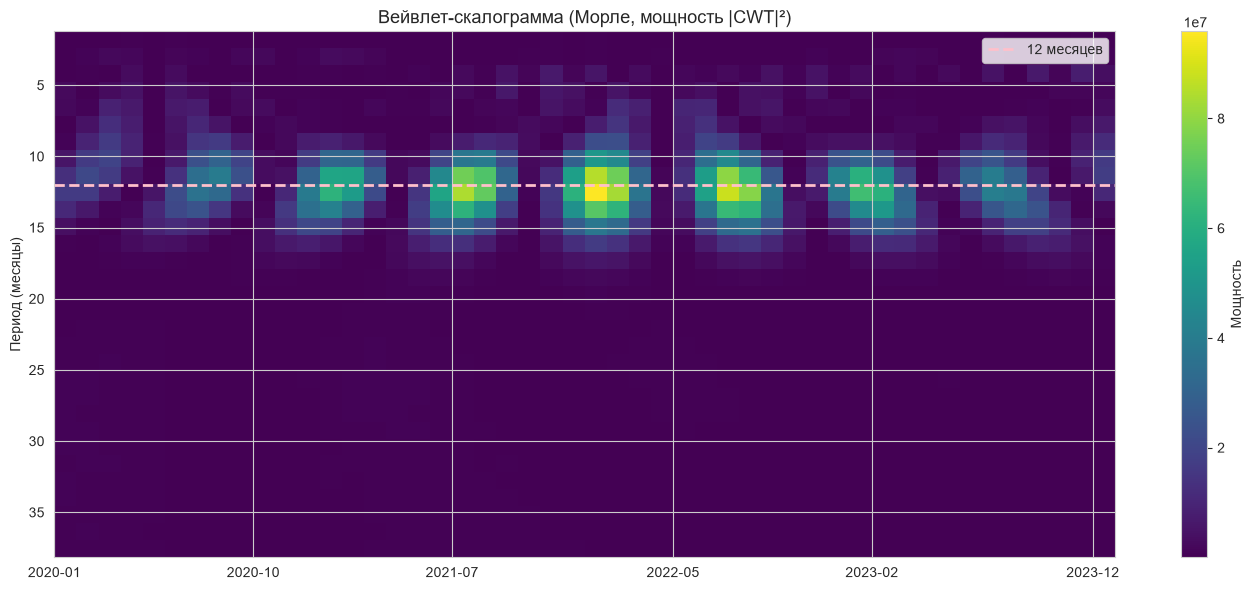

In [94]:
# Вейвлет Морле
# Берем ряд без окна Ханна: окно гасит края ряда, и 2020 и 2023 годы на скалограмме выглядят слабее, чем есть на самом деле
scales = np.arange(1, 32)
coeffs_morl, freqs_morl = pywt.cwt(y_detrended, scales, 'morl', sampling_period=1)
power_morl = np.abs(coeffs_morl) ** 2      # мощность это квадрат модуля

# Масштаб и период это не одно и то же: период = 1 / частота (для Морле период примерно в 1.23 раза больше масштаба)
periods_morl = 1 / freqs_morl

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(power_morl,
               extent=[0, n, periods_morl[-1], periods_morl[0]],
               cmap='viridis', aspect='auto')
ax.axhline(12, color='pink', linestyle='--', linewidth=2, label='12 месяцев')
ax.set_ylabel('Период (месяцы)')
ax.set_title('Вейвлет-скалограмма (Морле, мощность |CWT|²)', fontsize=13)
ax.legend(loc='upper right')
plt.colorbar(im, ax=ax, label='Мощность')

xticks = np.linspace(0, n - 1, 6).astype(int)
ax.set_xticks(xticks)
ax.set_xticklabels([df.index[i].strftime('%Y-%m') for i in xticks])
plt.tight_layout(); plt.show()

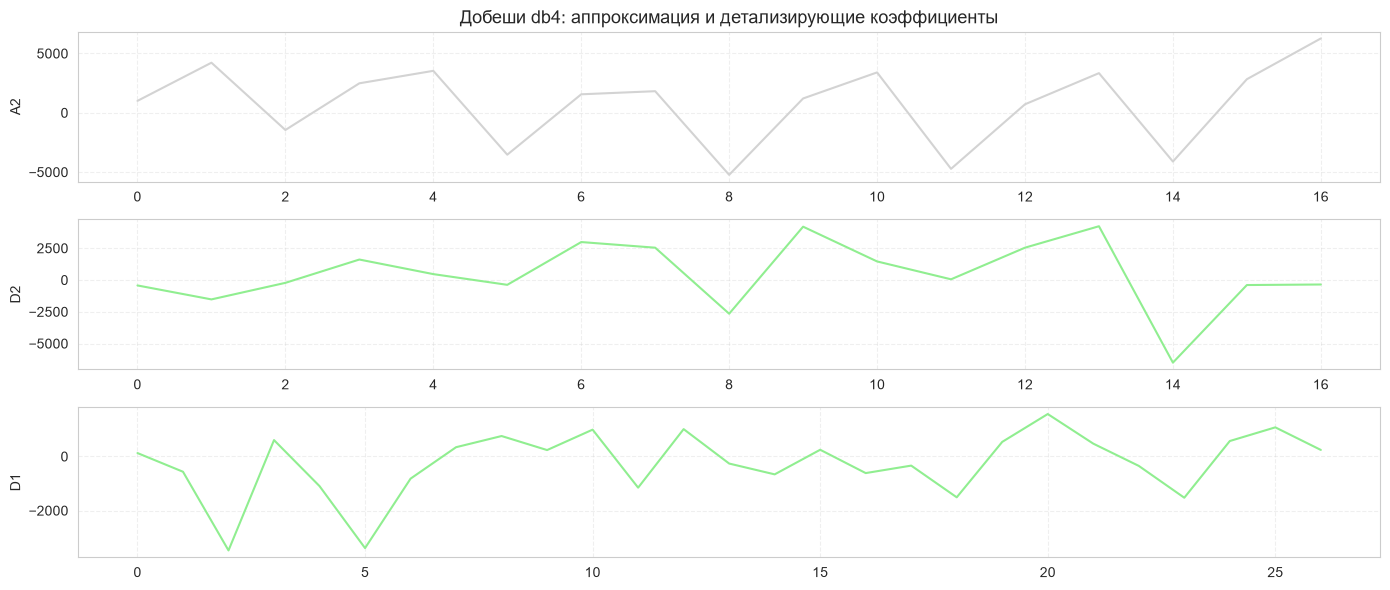

In [95]:
# Вейвлет Добеши (тоже без окна Ханна)
wavelet = 'db4'
max_level = pywt.dwt_max_level(n, wavelet)

coeffs_db = pywt.wavedec(y_detrended, wavelet, level=max_level)

# Первый элемент — аппроксимация (низкие частоты, тренд),
# Остальные — детали от крупномасштабных (cD_n) к мелкомасштабным (cD_1)
fig, axes = plt.subplots(max_level + 1, 1, figsize=(14, 2 * (max_level + 1)), sharex=False)

axes[0].plot(coeffs_db[0], color='lightgray')
axes[0].set_ylabel('A%d' % max_level)
axes[0].set_title('Добеши db4: аппроксимация и детализирующие коэффициенты', fontsize=13)

for i, c in enumerate(coeffs_db[1:], start=1):
    level = max_level - i + 1
    axes[i].plot(c, color='lightgreen')
    axes[i].set_ylabel('D%d' % level)

for a in axes:
    a.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout(); plt.show()

| Метод | Тип | Что дает | Плюсы | Минусы |
|---|---|---|---|---|
| CWT, Морле | Непрерывный | Скалограмму — мощность по времени и масштабам | Видно, когда сезонность усиливается или ослабевает | Зависит от выбора `scales`, сложнее интерпретировать |
| DWT, Добеши db4 | Дискретный | Разложение на уровни (аппроксимация + детали) | Быстро, компактно, удобно для сжатия и фильтрации | Требует кратного 2^level числа точек, теряет информацию о времени |

Вейвлет Морле дает скалограмму, на которой видно мощное пятно на периоде около 12 месяцев, это устойчивая годовая сезонность (максимум мощности на периоде около 12.3 мес.). Ярче всего пятно в 2021-2022 годах, по краям ряда оно слабее, но у вейвлета на краях всегда есть краевые эффекты, поэтому по одной скалограмме нельзя уверенно сказать, что сезонность реально меняется со временем.

Добеши на 48 точках раскладывает ряд всего на 2 уровня: D1 и D2 это быстрые колебания и шум (периоды до 8 месяцев), а в A2 остаются тренд и годовая сезонность вместе, то есть отдельно годовую сезонность он не выделяет.

| Метод | Что показал | Преимущество | Ограничение |
|---|---|---|---|
| Аддитивная декомпозиция | Стабильный годовой сезонный рисунок | Простая интерпретация в исходных единицах | Фиксированный период сезонности |
| Мультипликативная декомпозиция | Тот же годовой рисунок, но в относительном масштабе | Удобна, если амплитуда растет вместе с уровнем ряда | Требует положительных значений и читается сложнее |
| STL (robust) | Наибольшую силу сезонности и более устойчивые остатки | Гибкая сезонность, устойчивость к выбросам | Нужно задавать период и параметр сглаживания |
| FFT | Доминирующий пик на периоде 12 месяцев и его гармоники | Быстро и количественно находит глобальные периоды | Не локализует период во времени, чувствителен к длине ряда |
| Вейвлет Морле | Устойчивое пятно мощности на периоде ≈ 12 месяцев | Дает частотно-временное разрешение | Результат зависит от выбора вейвлета и набора масштабов |
| Вейвлет Добеши | Быстрые колебания и шум (D1, D2) и медленную часть (A2: тренд вместе с сезонностью) | Компактно отделяет шум и короткие колебания | На 48 точках всего 2 уровня, годовую сезонность от тренда не отделяет |

Все методы подтверждают годовую сезонность (s = 12) и слабый тренд. Ряд ближе к аддитивной модели, разница между аддитивным и мультипликативным разложениями минимальна, амплитуда сезонных колебаний слабо зависит от уровня продаж. Для SARIMAX принимаем `D = 1, s = 12`, а нужна ли еще и обычная разность `d` (0 или 1), выберем при подборе порядков.

---
# 2.2. Построение прогнозных моделей ARIMA и SARIMAX

Тренировочные данные с 2020 по 2022 год (36 мес.)  
Тестовые данные - весь 2023 (12 мес.)


ARIMA использует историю ряда без сезонности и без экзогенных признаков.
SARIMAX это ARIMA плюс сезонная часть и экзогенные признаки (промо и праздники).

Сначала посмотрим итоги EDA, поймем, какие параметры брать, потом переберем порядки по AIC, сделаем прогноз на 12 месяцев, а в конце посмотрим, насколько далеко можно прогнозировать.

In [96]:
# Целевая переменная и экзогенные признаки
target = df['SalesAmount']
exog = df[['Promotion', 'HolidayMonth']]

# Делим по времени на трейн и тест
train_y, test_y = target[:'2022-12-01'], target['2023-01-01':]
train_X, test_X = exog[:'2022-12-01'], exog['2023-01-01':]

print(f'Train: {len(train_y)}  Test: {len(test_y)}')

Train: 36  Test: 12


### 2.2.1. Какие параметры берем из EDA

Период сезонности `s = 12`, `D = 1`, `d = 0 или 1`, `p, q` от 0 до 1, `P, Q`, константа (`trend`), `Promotion`, `HolidayMonth`

In [97]:
# Смотрим, чем отличаются продажи в месяцы с промо и в праздничные месяцы
print(df.groupby('Promotion')['SalesAmount'].agg(['count', 'mean']).round(0))
print()
print(df.groupby('HolidayMonth')['SalesAmount'].agg(['count', 'mean']).round(0))

# Проверяем, не совпадает ли HolidayMonth просто с декабрем
print()
print('HolidayMonth это декабрь:', (df['HolidayMonth'] == (df.index.month == 12)).all())

           count     mean
Promotion                
0             42  11621.0
1              6  12800.0

              count     mean
HolidayMonth                
0                44  11410.0
1                 4  15718.0

HolidayMonth это декабрь: True


Видим, что в месяцы с промо продажи в среднем выше (12800 против 11621), но таких месяцев всего 6, так что в выводе быть уверенными нельзя. В праздничные месяцы разница намного больше (15718 против 11410), но это просто декабрь каждого года. То есть этот признак повторяется каждый год, как и сама сезонность, и это важно для SARIMAX.

### 2.2.2. Функции для подбора порядков (grid search по AIC)

In [98]:
import warnings
from statsmodels.tsa.arima.model import ARIMA

# Диапазоны порядков берем по итогам EDA
p = q = range(0, 2)      # в ACF и PACF значим только лаг 1, а точек мало, поэтому больше 1 не берем
P = Q = range(0, 2)      # сезонную часть тоже оставляем маленькой
d_list = [0, 1]          # ADF показал, что ряд стационарен и так, поэтому проверяем и d=0, и d=1
D = 1                    # одна сезонная разность
s = 12                   # годовая сезонность

# statsmodels считает AIC и BIC не по всем точкам. Из-за разностей начало ряда пропускается
# (у SARIMAX с D=1 это 12-13 точек, у ARIMA 0-1). Из-за этого у разных моделей AIC просто так сравнивать нельзя
# Поэтому считаем сами, по одним и тем же точкам, начиная с 14-й
BURN = 13

def aic_bic(res, burn=BURN):
    llf = res.llf_obs[burn:].sum()          # логарифм правдоподобия по общим точкам
    k = len(res.params)                     # число параметров модели
    n = len(res.llf_obs) - burn             # число точек
    return -2 * llf + 2 * k, -2 * llf + k * np.log(n)

# При маленьком числе точек по AIC часто побеждают вырожденные модели, какой-то из коэффициентов
# упирается в границу допустимого и оценкам такой модели верить нельзя.
# Такие модели отсеиваем. Возьму например порог 1.05
ROOT_MIN = 1.05

def min_root(res):
    roots = np.concatenate([np.abs(res.arroots), np.abs(res.maroots)])
    return roots.min() if len(roots) else np.inf

def sane(grid_df):
    return grid_df[grid_df['root'] >= ROOT_MIN].reset_index(drop=True)

def pick_arima(grid_df):
    # Возьмем d=0 (ADF показал, что ряд стационарен, как и в SARIMAX) и хотя бы один AR или MA,
    # иначе получится просто среднее. Прогноз у такой ARIMA хотя бы плавно идет к среднему
    return grid_df[grid_df['order'].apply(lambda o: o[1] == 0 and o[0] + o[2] > 0)].reset_index(drop=True)

def fit_sarimax(y, X, order, sorder, trend=None):
    # enforce_stationarity и enforce_invertibility оставим, чтобы вдруг на длинных горизонтах не улетели
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return SARIMAX(y, exog=X, order=order, seasonal_order=sorder, trend=trend).fit(disp=False, maxiter=200)

def grid_arima(y):
    # Перебор ARIMA(p, d, q). Без сезонности и без экзогенных признаков
    rows = []
    for d in d_list:
        # При d=0 нужна константа (уровень продаж около 11 тыс.), при d=1 пробуем без дрейфа n и с дрейфом t
        trends = ['c'] if d == 0 else ['n', 't']
        for trend in trends:
            for order in itertools.product(p, [d], q):
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        m = ARIMA(y, order=order, trend=trend).fit()
                    # Берем модели, где оптимизатор сошелся
                    if not m.mle_retvals.get('converged', True):
                        continue
                    aic, bic = aic_bic(m)
                    rows.append({'order': order, 'trend': trend, 'AIC': aic, 'BIC': bic,
                                 'root': min_root(m), 'model': m})
                except Exception:
                    continue
    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

def grid_sarimax(y, X):
    # Перебор SARIMAX(p, d, q)(P, D, Q, s) с экзогенными признаками
    rows = []
    for d in d_list:
        # Константа (trend='c') после сезонной разности это годовой прирост продаж, в EDA был слабый восходящий тренд.
        # При d=1 ее не берем, иначе получится квадратичный тренд
        trends = [None, 'c'] if d == 0 else [None]
        for trend in trends:
            for order in itertools.product(p, [d], q):
                for sorder in itertools.product(P, [D], Q, [s]):
                    try:
                        m = fit_sarimax(y, X, order, sorder, trend)
                        if not m.mle_retvals['converged']:
                            continue
                        aic, bic = aic_bic(m)
                        rows.append({'order': order, 'seasonal': sorder, 'trend': trend,
                                     'AIC': aic, 'BIC': bic, 'root': min_root(m), 'model': m})
                    except Exception:
                        continue
    return pd.DataFrame(rows).sort_values('AIC').reset_index(drop=True)

### 2.2.3. Grid search по порядкам ARIMA (без сезонности и без экзогенных)

In [99]:
# фильтруем модели
arima_all = sane(grid_arima(train_y))
print('Топ по AIC:')
display(arima_all[['order', 'trend', 'AIC', 'BIC', 'root']].head(5))

# Оставляем только d=0 и хотя бы с одним AR или MA
arima_df = pick_arima(arima_all)
print('Топ по AIC после отбора:')
arima_df[['order', 'trend', 'AIC', 'BIC', 'root']].head(5)

Топ по AIC:


,order,trend,AIC,BIC,root
0,"(0, 1, 0)",n,414.282449,415.417943,inf
1,"(1, 0, 0)",c,415.715256,419.121739,2.024000
2,"(0, 1, 0)",t,416.050376,418.321364,inf
3,"(0, 1, 1)",n,416.352037,418.623026,9.218835
4,"(1, 1, 0)",n,417.141199,419.412188,9.249499


Топ по AIC после отбора:


,order,trend,AIC,BIC,root
0,"(1, 0, 0)",c,415.715256,419.121739,2.024000
1,"(1, 0, 1)",c,417.827770,422.369747,2.096487
2,"(0, 0, 1)",c,418.325241,421.731724,2.717809


### 2.2.4. Grid search по порядкам SARIMAX (сезонность + экзогенные)

In [100]:
sarimax_all = grid_sarimax(train_y, train_X)

# Сначала посмотрим топ по AIC без фильтров. У самой первой модели root = 1.0, ее сезонный MA коэффициент
# уперся в -1, то есть модель вырожденная
print('Топ по AIC без фильтра:')
display(sarimax_all[['order', 'seasonal', 'trend', 'AIC', 'BIC', 'root']].head(5))

# Теперь фильтруем модели
sarimax_df = sane(sarimax_all)
print(f'Отброшено вырожденных моделей: {len(sarimax_all) - len(sarimax_df)} из {len(sarimax_all)}')
print('Топ по AIC после фильтра:')
sarimax_df[['order', 'seasonal', 'trend', 'AIC', 'BIC', 'root']].head(5)

Топ по AIC без фильтра:


,order,seasonal,trend,AIC,BIC,root
0,"(0, 0, 0)","(1, 1, 1, 12)",c,375.292516,382.105481,1.000000
1,"(0, 0, 1)","(0, 1, 1, 12)",c,375.482103,382.295068,1.090928
2,"(1, 0, 0)","(0, 1, 1, 12)",c,375.531775,382.344740,1.091613
3,"(0, 0, 1)","(1, 1, 0, 12)",c,375.747923,382.560888,1.121597
4,"(1, 0, 0)","(1, 1, 1, 12)",c,377.195326,385.143786,1.000000


Отброшено вырожденных моделей: 12 из 48
Топ по AIC после фильтра:


,order,seasonal,trend,AIC,BIC,root
0,"(0, 0, 1)","(0, 1, 1, 12)",c,375.482103,382.295068,1.090928
1,"(1, 0, 0)","(0, 1, 1, 12)",c,375.531775,382.344740,1.091613
2,"(0, 0, 1)","(1, 1, 0, 12)",c,375.747923,382.560888,1.121597
3,"(1, 0, 1)","(1, 1, 0, 12)",c,377.306091,385.254551,1.120326
4,"(1, 0, 1)","(0, 1, 1, 12)",c,377.381559,385.330018,1.090929


- ARIMA по чистому AIC лучше всех вышло случайное блуждание ARIMA(0, 1, 0), то есть прогноз равен последнему значению (плоская линия). Это не настоящая модель, и вообще любая несезонная ARIMA с `d = 1` дает прогноз-константу. Поэтому я взял `d = 0` (ADF показал, что ряд стационарен, как и в SARIMAX) и хотя бы один AR или MA член: получилась ARIMA(1, 0, 0) с константой
- SARIMAX, если смотреть просто на AIC, то первой идет (0, 0, 0)(1, 1, 1, 12), но у нее корень ровно 1.00, сезонный MA коэффициент уперся в -1, значит модель вырожденная. На 23 точках так получается часто, поэтому я отбросил модели с корнем меньше 1.05 (12 из 48) и взял лучшую из оставшихся: SARIMAX(0, 0, 1)(0, 1, 1, 12) с константой.
- Для SARIMAX хватило `d = 0`, как и показывал ADF. Сезонной разности достаточно. Константа в модели осталась, значит слабый восходящий тренд учитывается.

### 2.2.5. Обучение финальных моделей

In [101]:
# Берем лучшие по AIC, уже обученные на тренировочной выборке
arima_model = arima_df.loc[0, 'model']
sarimax_model = sarimax_df.loc[0, 'model']

arima_order, arima_trend = arima_df.loc[0, 'order'], arima_df.loc[0, 'trend']
sarimax_order, sarimax_sorder = sarimax_df.loc[0, 'order'], sarimax_df.loc[0, 'seasonal']
sarimax_trend = sarimax_df.loc[0, 'trend']

print('ARIMA:  ', arima_order, 'trend =', arima_trend)
print('SARIMAX:', sarimax_order, sarimax_sorder, 'trend =', sarimax_trend)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    coef_table = pd.DataFrame({'coef': sarimax_model.params,
                               'std err': sarimax_model.bse,
                               'p-value': sarimax_model.pvalues}).round(4)
coef_table

ARIMA:   (1, 0, 0) trend = c
SARIMAX: (0, 0, 1) (0, 1, 1, 12) trend = c


,coef,std err,p-value
intercept,1000.4639,215.4460,0.0000
Promotion,2624.5779,316.9273,0.0000
HolidayMonth,2.3470,10610.8461,0.9998
ma.L1,0.0226,0.1422,0.8736
ma.S.L12,-0.3519,0.1747,0.0439
sigma2,387069.6020,182115.7777,0.0336


Смотрим на коэффициенты SARIMAX:

- `intercept` около 1000 и значим. После сезонной разности это годовой прирост. Еаждый месяц в среднем на 1000 выше, чем в прошлом году. Это самый слабый восходящий тренд из EDA.
- `Promotion` около 2600 и значим: в месяц с промо продажи выше примерно на 2600.
- `HolidayMonth` со стандартной ошибкой 10610 и p-value почти 1, то есть модель его вообще не оценила. Причина в том, что это просто декабрь, а сезонная разность `D = 1` убирает любой признак, который повторяется каждый год. Декабрьский пик SARIMAX берет из сезонной разности, а не из этого признака. Проверим, что без него прогноз такой же.
- Сезонный `ma.S.L12` значим (p = 0.04)

### 2.2.6. Прогноз на тестовый горизонт (12 месяцев)

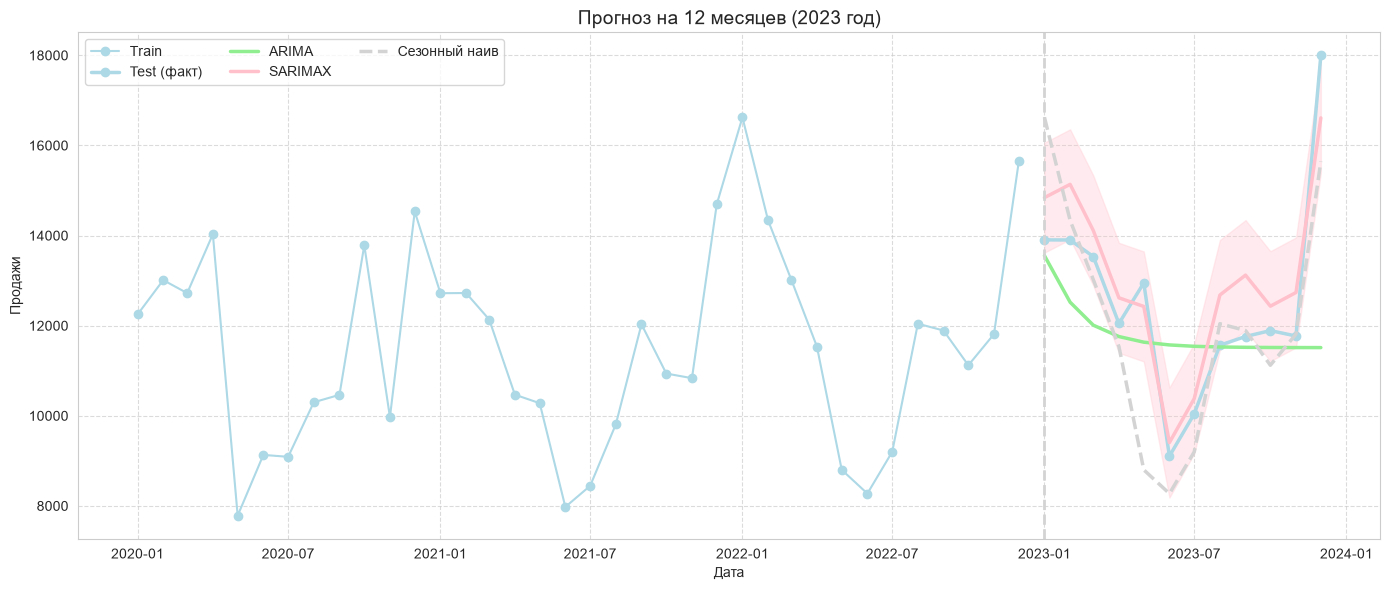

In [102]:
steps = len(test_y)

# SARIMAX нужны значения Promotion и HolidayMonth на тестовый период, берем их из test_X
forecast_sarimax = sarimax_model.get_forecast(steps=steps, exog=test_X)
pred_sarimax = forecast_sarimax.predicted_mean
ci_sarimax = forecast_sarimax.conf_int()

# ARIMA прогнозирует только по своей истории
pred_arima = arima_model.get_forecast(steps=steps).predicted_mean

# Просто повторяем последние 12 месяцев обучения
pred_naive = pd.Series(np.resize(train_y.values[-12:], steps), index=test_y.index)

# Цвета моделей
colors = {'Факт': 'lightblue', 'ARIMA': 'lightgreen', 'SARIMAX': 'pink', 'Сезонный наив': 'lightgray'}

def plot_forecast(y_train, y_test, preds, cis, title):
    fig, ax = plt.subplots(figsize=(14, 6))
    # История и факт на тесте
    ax.plot(y_train.index, y_train, marker='o', color=colors['Факт'], label='Train')
    ax.plot(y_test.index, y_test, marker='o', color=colors['Факт'], linewidth=2.5, label='Test (факт)')
    # Прогнозы моделей
    for name, pred in preds.items():
        style = '--' if name == 'Сезонный наив' else '-'
        ax.plot(pred.index, pred, linestyle=style, linewidth=2.5, color=colors[name], label=name)
    for name, ci in cis.items():
        ax.fill_between(ci.index, ci.iloc[:, 0], ci.iloc[:, 1], color=colors[name], alpha=0.3)
    # Линия, где кончается обучение
    ax.axvline(y_test.index[0], color='lightgray', linestyle='--', linewidth=2)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Дата'); ax.set_ylabel('Продажи')
    ax.grid(True, alpha=0.7, linestyle='--')
    ax.legend(ncol=3, loc='upper left')
    plt.tight_layout(); plt.show()

plot_forecast(train_y, test_y,
              {'ARIMA': pred_arima, 'SARIMAX': pred_sarimax, 'Сезонный наив': pred_naive},
              {'SARIMAX': ci_sarimax},
              'Прогноз на 12 месяцев (2023 год)')

In [103]:
# Проверим, если выкинуть HolidayMonth, поменяется ли прогноз SARIMAX
sarimax_promo = fit_sarimax(train_y, train_X[['Promotion']], sarimax_order, sarimax_sorder, sarimax_trend)
pred_promo = sarimax_promo.get_forecast(steps=steps, exog=test_X[['Promotion']]).predicted_mean

print(f'R2 с Promotion и HolidayMonth: {r2_score(test_y, pred_sarimax):.3f}')
print(f'R2 только с Promotion:         {r2_score(test_y, pred_promo):.3f}')
print(f'Максимальная разница прогнозов: {np.abs(pred_sarimax - pred_promo).max():.1f}')

R2 с Promotion и HolidayMonth: 0.824
R2 только с Promotion:         0.824
Максимальная разница прогнозов: 0.1


Видим, что SARIMAX повторяет форму года (провал в мае-июне и пик в декабре) и близок к факту. ARIMA начинает с уровня около 13.5 тыс., за несколько месяцев спадает к среднему (около 11.5 тыс.) и дальше идет почти ровной линией. Обычная ARIMA не умеет повторять годовую форму. Из-за этого она сильно недооценивает декабрь и завышает июнь-июль. Сезонный наив повторяет форму, но ничего не знает про промо. Декабрь 2023 (17996) выше прогнозов всех моделей.

Проверка показала, что без `HolidayMonth` R² не меняется (0.824 в обоих случаях), то есть он действительно ничего не дает.

### 2.2.7. Максимальный горизонт прогноза

По заданию нужен прогноз на максимальный горизонт, где качество еще приемлемое. Всего у нас 48 точек, поэтому чем длиннее горизонт, тем короче остается обучение. Пробуем горизонты от 3 до 24 месяцев: последние H месяцев идут в тест, остальное в обучение, порядки подбираем заново и считаем MSE и R^2. Приемлемым считаем прогноз, если R^2 не ниже 0.7 и MSE меньше, чем у сезонного наива. Порог 0.7 выбрал сам

In [104]:
# Пробуем разные горизонты, последние H месяцев идут в тест, все остальное в обучение
horizons = [3, 6, 9, 12, 15, 18, 21, 24]
hor_rows = []
hor_store = {}

for H in horizons:
    n_train = len(target) - H
    y_tr, y_te = target.iloc[:n_train], target.iloc[n_train:]
    X_tr, X_te = exog.iloc[:n_train], exog.iloc[n_train:]

    # Порядки подбираем заново на каждой обучающей выборке, чтобы не подглядывать в тест
    a_row = pick_arima(sane(grid_arima(y_tr))).loc[0]
    s_row = sane(grid_sarimax(y_tr, X_tr)).loc[0]

    f_s = s_row['model'].get_forecast(H, exog=X_te)
    p_a = a_row['model'].get_forecast(H).predicted_mean
    p_s = f_s.predicted_mean
    p_n = pd.Series(np.resize(y_tr.values[-12:], H), index=y_te.index)

    hor_store[H] = {'y_tr': y_tr, 'y_te': y_te, 'preds': {'ARIMA': p_a, 'SARIMAX': p_s, 'Сезонный наив': p_n},
                    'cis': {'SARIMAX': f_s.conf_int()}}
    hor_rows.append({
        'H': H, 'Обучение': n_train,
        'ARIMA': str(a_row['order']) + (' +дрейф' if a_row['trend'] == 't' else ''),
        'SARIMAX': str(s_row['order']) + str(s_row['seasonal'][:3]) + (' +const' if s_row['trend'] == 'c' else ''),
        'MSE ARIMA': mean_squared_error(y_te, p_a), 'R2 ARIMA': r2_score(y_te, p_a),
        'MSE SARIMAX': mean_squared_error(y_te, p_s), 'R2 SARIMAX': r2_score(y_te, p_s),
        'MSE наив': mean_squared_error(y_te, p_n), 'R2 наив': r2_score(y_te, p_n),
    })

hor_df = pd.DataFrame(hor_rows).set_index('H')

# Считаем прогноз приемлемым, если R2 не ниже 0.7 и MSE меньше, чем у сезонного наива
# (иначе проще повторять прошлый год и модель не нужна)
hor_df['Приемлемо'] = (hor_df['R2 SARIMAX'] >= 0.7) & (hor_df['MSE SARIMAX'] < hor_df['MSE наив'])

# Максимальный горизонт: самый длинный из приемлемых
H_max = hor_df.index[hor_df['Приемлемо']].max()

print(f'Максимальный горизонт с приемлемым качеством: {H_max} мес.')
hor_df.round(2)

Максимальный горизонт с приемлемым качеством: 21 мес.


,Обучение,ARIMA,SARIMAX,MSE ARIMA,R2 ARIMA,MSE SARIMAX,R2 SARIMAX,MSE наив,R2 наив,Приемлемо
H,,,,,,,,,,
3,45,"(1, 0, 0)","(0, 0, 0)(1, 1, 0) +const",13467064.59,-0.59,1129549.47,0.87,2040108.67,0.76,True
6,42,"(1, 0, 0)","(0, 0, 0)(1, 1, 0) +const",6896349.48,-0.07,877212.41,0.86,1179365.50,0.82,True
9,39,"(1, 0, 0)","(0, 0, 0)(1, 1, 0) +const",5784387.99,-0.06,666261.13,0.88,2804675.11,0.49,True
12,36,"(1, 0, 0)","(0, 0, 1)(0, 1, 1) +const",4733414.56,-0.02,815224.53,0.82,2757115.25,0.40,True
15,33,"(1, 0, 0)","(0, 0, 1)(0, 1, 1) +const",5938047.24,-0.32,843149.73,0.81,2768686.87,0.39,True
18,30,"(1, 0, 0)","(0, 0, 1)(1, 1, 0) +const",5122901.73,-0.17,732405.82,0.83,2880916.17,0.34,True
21,27,"(1, 0, 0)","(0, 0, 0)(1, 1, 0) +const",5278426.37,-0.05,592990.32,0.88,2286033.48,0.54,True
24,24,"(1, 0, 0)","(0, 0, 0)(0, 1, 0)",6016155.39,-0.10,2045931.04,0.63,2646821.12,0.52,False


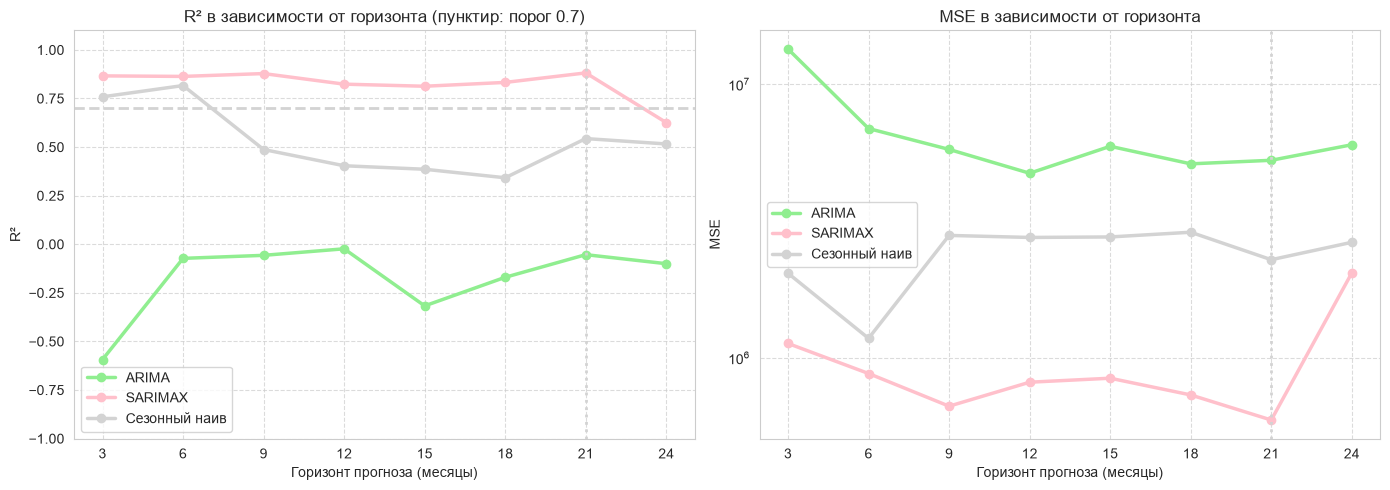

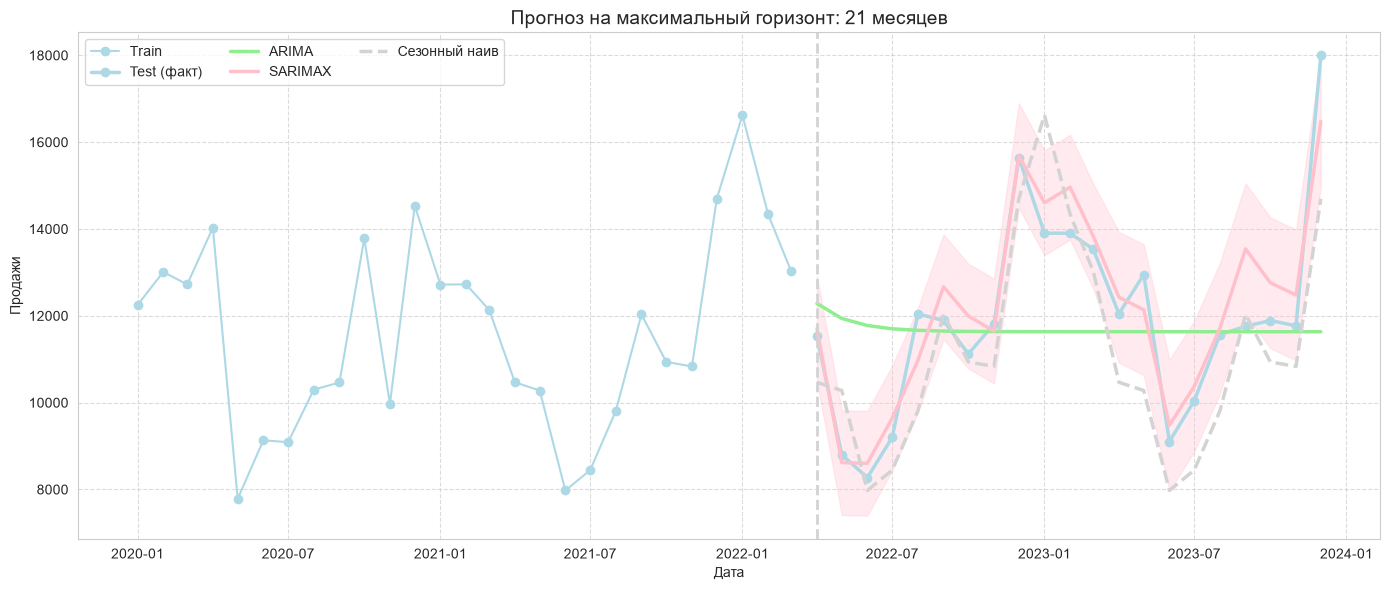

In [105]:
# Проверим по графикам, как меняется качество SARIMAX и ARIMA с ростом горизонта
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, col_r2, col_mse in [('ARIMA', 'R2 ARIMA', 'MSE ARIMA'),
                              ('SARIMAX', 'R2 SARIMAX', 'MSE SARIMAX'),
                              ('Сезонный наив', 'R2 наив', 'MSE наив')]:
    axes[0].plot(hor_df.index, hor_df[col_r2], marker='o', linewidth=2.5, color=colors[name], label=name)
    axes[1].plot(hor_df.index, hor_df[col_mse], marker='o', linewidth=2.5, color=colors[name], label=name)

axes[0].axhline(0.7, color='lightgray', linestyle='--', linewidth=2)
axes[0].set_title('R² в зависимости от горизонта (пунктир: порог 0.7)')
axes[0].set_ylabel('R²'); axes[0].set_ylim(-1, 1.1)

# MSE у ARIMA сильно больше остальных, поэтому ось Y логарифмическая
axes[1].set_title('MSE в зависимости от горизонта')
axes[1].set_ylabel('MSE'); axes[1].set_yscale('log')

for a in axes:
    a.axvline(H_max, color='lightgray', linestyle=':', linewidth=2)
    a.set_xlabel('Горизонт прогноза (месяцы)')
    a.set_xticks(hor_df.index)
    a.grid(True, alpha=0.7, linestyle='--')
    a.legend()
plt.tight_layout(); plt.show()

# Прогноз на максимальный горизонт
st = hor_store[H_max]
plot_forecast(st['y_tr'], st['y_te'], st['preds'], st['cis'], f'Прогноз на максимальный горизонт: {H_max} месяцев')

Видим, что SARIMAX держит R^2 около 0.8-0.9 на всех горизонтах от 3 до 21 месяца (MSE от 0.6 до 1.1 млн, у сезонного наива от 1.2 до 2.9 млн). На 24 месяцах качество падает: R^2 = 0.63, порог 0.7 не пройден. В обучении остается всего 24 точки, это два года, после сезонной разности остается 12 точек. Модель уже не может надежно оценить константу и сезонную часть, и в сетке побеждает самый простой вариант (0, 0, 0)(0, 1, 0, 12) без константы. Поэтому максимальный горизонт получился 21 месяц.

ARIMA на всех горизонтах плохая (R^2 от -0.59 до -0.02), то есть она не лучше, чем если бы мы просто предсказывали среднее. Без сезонности ничего полезного она дать не может.

На разных горизонтах тестовые отрезки разные, поэтому R^2 сравнивать нужно аккуратно. Чем дальше горизонт, тем шире доверительный интервал, я бы ориентировался на 12 месяцев, а 21 это верхняя граница.

### 2.2.8. Прогноз вперед (за пределы данных)

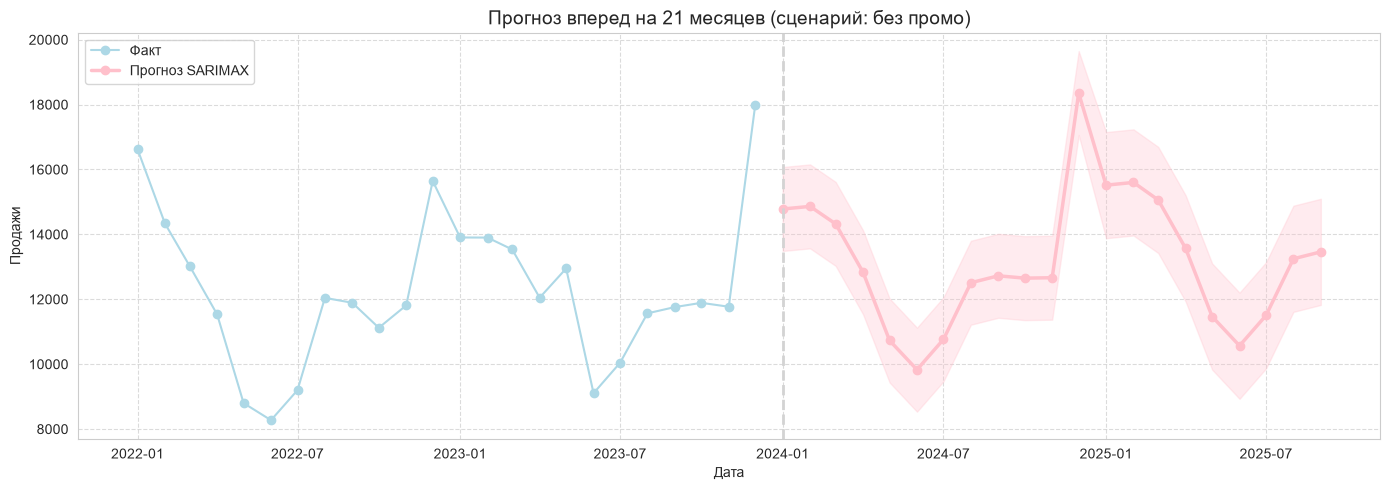

In [106]:
# Переобучаем SARIMAX на всех 48 месяцах и прогнозируем на H_max месяцев вперед
future_index = pd.date_range(target.index[-1] + pd.offsets.MonthBegin(1), periods=H_max, freq='MS')

# Будущих значений признаков мы не знаем, поэтому задаем сценарий: промо нет, праздничный месяц это декабрь
future_X = pd.DataFrame({'Promotion': 0,
                         'HolidayMonth': (future_index.month == 12).astype(int)}, index=future_index)

final_model = fit_sarimax(target, exog, sarimax_order, sarimax_sorder, sarimax_trend)
future = final_model.get_forecast(H_max, exog=future_X)
future_pred = future.predicted_mean
future_ci = future.conf_int()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(target.index[-24:], target.iloc[-24:], marker='o', color=colors['Факт'], label='Факт')
ax.plot(future_pred.index, future_pred, marker='o', linewidth=2.5, color=colors['SARIMAX'], label='Прогноз SARIMAX')
ax.fill_between(future_ci.index, future_ci.iloc[:, 0], future_ci.iloc[:, 1], color=colors['SARIMAX'], alpha=0.3)
ax.axvline(future_index[0], color='lightgray', linestyle='--', linewidth=2)
ax.set_title(f'Прогноз вперед на {H_max} месяцев (сценарий: без промо)', fontsize=14)
ax.set_xlabel('Дата'); ax.set_ylabel('Продажи')
ax.grid(True, alpha=0.7, linestyle='--')
ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

### Выводы по п. 2.2

- Из EDA взяли `s = 12` и `D = 1` (FFT, вейвлет, STL, ACF), небольшие `p, q, P, Q` и константу (слабый тренд). Нужна ли обычная разность `d`, оставили на grid search, и SARIMAX выбрал `d = 0`, как и подсказывал ADF. Для ARIMA тоже взяли `d = 0`.
- По AIC первым шло случайное блуждание ARIMA(0, 1, 0), но это просто последнее значение (любая несезонная ARIMA с `d = 1` дает константу), поэтому взяли ARIMA(1, 0, 0) с константой. Без сезонности она быстро выходит на среднее и годовую форму не повторяет. SARIMAX(0, 0, 1)(0, 1, 1, 12) с константой и признаками, вырожденные модели (корни около 1) отбросили.
- В SARIMAX реально работают сезонная разность, константа (годовой прирост около 1000) и `Promotion` (около 2600). `HolidayMonth` не работает, а сезонная разность его уже учла.
- Максимальный горизонт с приемлемым качеством получился 21 месяц (R^2 не ниже 0.7), на 24 месяцах качество падает из-за малого числа обучающих точек. Надежнее 12 месяцев.

---
# 2.3. Оценка качества моделей

### 2.3.1. MSE, R², AIC, BIC

In [107]:
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return mse, r2

# Метрики на тесте за 2023 год
mse_a, r2_a = metrics(test_y, pred_arima)
mse_s, r2_s = metrics(test_y, pred_sarimax)
mse_n, r2_n = metrics(test_y, pred_naive)

# AIC и BIC считаем по общим точкам, а рядом для справки значения из statsmodels
aic_a, bic_a = aic_bic(arima_model)
aic_s, bic_s = aic_bic(sarimax_model)

model_names = [f'ARIMA{arima_order}' + (' +дрейф' if arima_trend == 't' else ''),
               f'SARIMAX{sarimax_order}x{sarimax_sorder}' + (' +const' if sarimax_trend == 'c' else ''),
               'Сезонный наив']

metrics_df = pd.DataFrame({
    'Модель': model_names,
    'MSE': [mse_a, mse_s, mse_n],
    'R2': [r2_a, r2_s, r2_n],
    'AIC': [aic_a, aic_s, np.nan],
    'BIC': [bic_a, bic_s, np.nan],
    'AIC (statsmodels)': [arima_model.aic, sarimax_model.aic, np.nan],
    'BIC (statsmodels)': [arima_model.bic, sarimax_model.bic, np.nan],
}).set_index('Модель').round(2)
metrics_df

,MSE,R2,AIC,BIC,AIC (statsmodels),BIC (statsmodels)
Модель,,,,,,
"ARIMA(1, 0, 0)",4733414.56,-0.02,415.72,419.12,653.07,657.82
"SARIMAX(0, 0, 1)x(0, 1, 1, 12) +const",815224.53,0.82,375.48,382.30,390.79,397.86
Сезонный наив,2757115.25,0.40,NaN,NaN,NaN,NaN


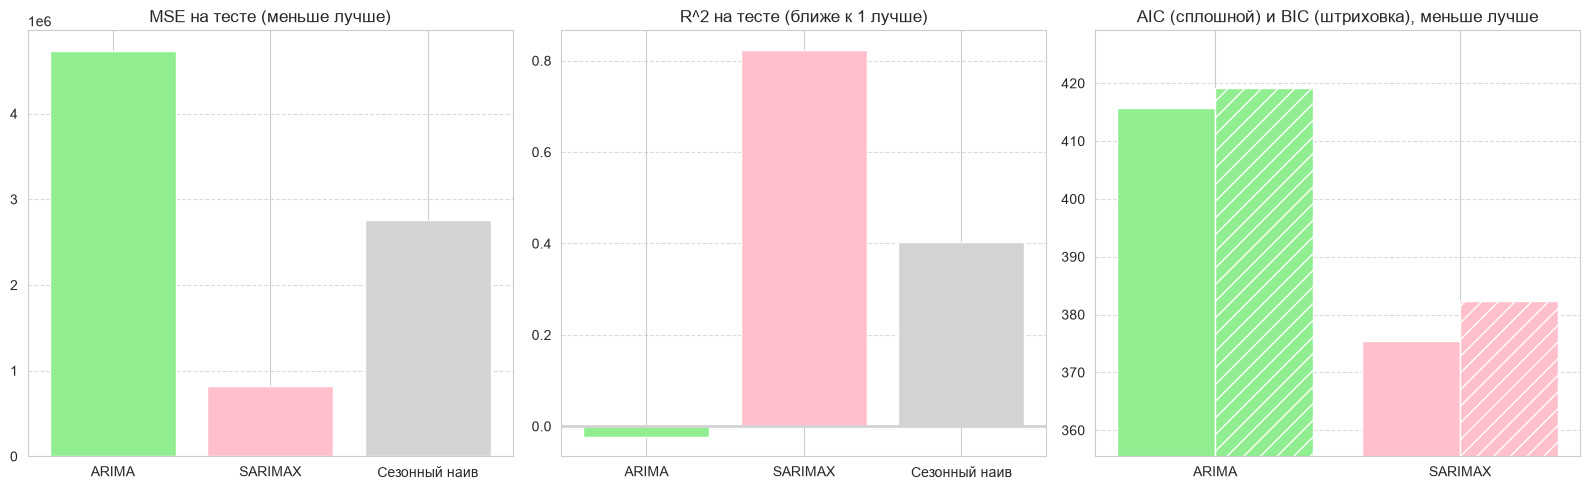

In [108]:
# Теперь в виде графиков
bar_colors = [colors['ARIMA'], colors['SARIMAX'], colors['Сезонный наив']]
short_names = ['ARIMA', 'SARIMAX', 'Сезонный наив']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE
axes[0].bar(short_names, [mse_a, mse_s, mse_n], color=bar_colors)
axes[0].set_title('MSE на тесте (меньше лучше)')

# R^2
axes[1].bar(short_names, [r2_a, r2_s, r2_n], color=bar_colors)
axes[1].axhline(0, color='lightgray', linewidth=2)
axes[1].set_title('R^2 на тесте (ближе к 1 лучше)')

# AIC и BIC
x = np.arange(2)
axes[2].bar(x - 0.2, [aic_a, aic_s], width=0.4, color=[colors['ARIMA'], colors['SARIMAX']], label='AIC')
axes[2].bar(x + 0.2, [bic_a, bic_s], width=0.4, color=[colors['ARIMA'], colors['SARIMAX']], hatch='//', label='BIC')
axes[2].set_xticks(x); axes[2].set_xticklabels(['ARIMA', 'SARIMAX'])
axes[2].set_ylim(min(aic_a, aic_s) - 20, max(bic_a, bic_s) + 10)
axes[2].set_title('AIC (сплошной) и BIC (штриховка), меньше лучше')

for a in axes:
    a.grid(True, alpha=0.7, linestyle='--', axis='y')
plt.tight_layout(); plt.show()

In [109]:
# Где именно модели ошибаются
# ошибка = прогноз, факт по каждому месяцу теста
err_df = pd.DataFrame({
    'Факт': test_y,
    'Promotion': test_X['Promotion'],
    'Ошибка ARIMA': pred_arima - test_y,
    'Ошибка SARIMAX': pred_sarimax - test_y,
    'Ошибка наива': pred_naive - test_y,
})
err_df.index = err_df.index.strftime('%Y-%m')
display(err_df.round(0))

# Месяцы, где промо отличается от того же месяца год назад: там SARIMAX и сезонный наив прогнозируют по-разному
promo_changed = test_X['Promotion'] != exog['Promotion'].shift(12)[test_y.index]
print('Месяцы, где промо изменилось по сравнению с прошлым годом:', list(test_y.index[promo_changed].strftime('%Y-%m')))
for name, pred in [('SARIMAX', pred_sarimax), ('Сезонный наив', pred_naive)]:
    mse_in = mean_squared_error(test_y[promo_changed], pred[promo_changed])
    mse_out = mean_squared_error(test_y[~promo_changed], pred[~promo_changed])
    print(f'{name}: MSE в этих месяцах {mse_in:,.0f}, в остальных {mse_out:,.0f}')

,Факт,Promotion,Ошибка ARIMA,Ошибка SARIMAX,Ошибка наива
2023-01,13904,0,-350.0,937.0,2719
2023-02,13901,0,-1380.0,1235.0,435
2023-03,13534,0,-1524.0,579.0,-511
2023-04,12048,0,-290.0,569.0,-511
2023-05,12949,1,-1315.0,-523.0,-4149
2023-06,9104,0,2468.0,301.0,-831
2023-07,10042,0,1500.0,339.0,-843
2023-08,11566,0,-39.0,1113.0,477
2023-09,11759,0,-240.0,1362.0,133
2023-10,11890,0,-375.0,542.0,-769


Месяцы, где промо изменилось по сравнению с прошлым годом: ['2023-01', '2023-05']
SARIMAX: MSE в этих месяцах 576,011, в остальных 863,067
Сезонный наив: MSE в этих месяцах 12,303,581, в остальных 847,822


SARIMAX заметно лучше. MSE 0.82 млн против 4.73 млн у ARIMA и 2.76 млн у сезонного наива, R^2 = 0.82 против -0.02 и 0.40. У ARIMA R^2 около нуля, то есть она не лучше, чем если бы мы всегда предсказывали среднее теста. По AIC и BIC SARIMAX тоже лучше (375 против 416 по AIC и 382 против 419 по BIC). Эти числа посчитаны по одним и тем же 23 точкам, поэтому их можно сравнивать, а значения statsmodels нельзя: у разных моделей они считаются по разному числу точек.

По таблице ошибок ARIMA быстро спадает к среднему и не видит сезонности, поэтому декабрь недооценивает на 6.5 тыс., а июнь и июль завышает на 2.5 и 1.5 тыс.; SARIMAX ошибается не больше чем на 1.4 тыс. Декабрь 2023 все модели недооценили.

В десяти месяцах, где промо не менялось, SARIMAX и сезонный наив почти одинаковы (MSE 863 тыс. против 848 тыс.). Весь выигрыш SARIMAX над наивом приходится на январь (в январе 2022 было промо) и май (в мае 2023 было промо). То есть он держится на двух месяцах.

### 2.3.2. Анализ остатков (нормальность, автокорреляция, гомоскедастичность)

Остатков: ARIMA 36, SARIMAX 24


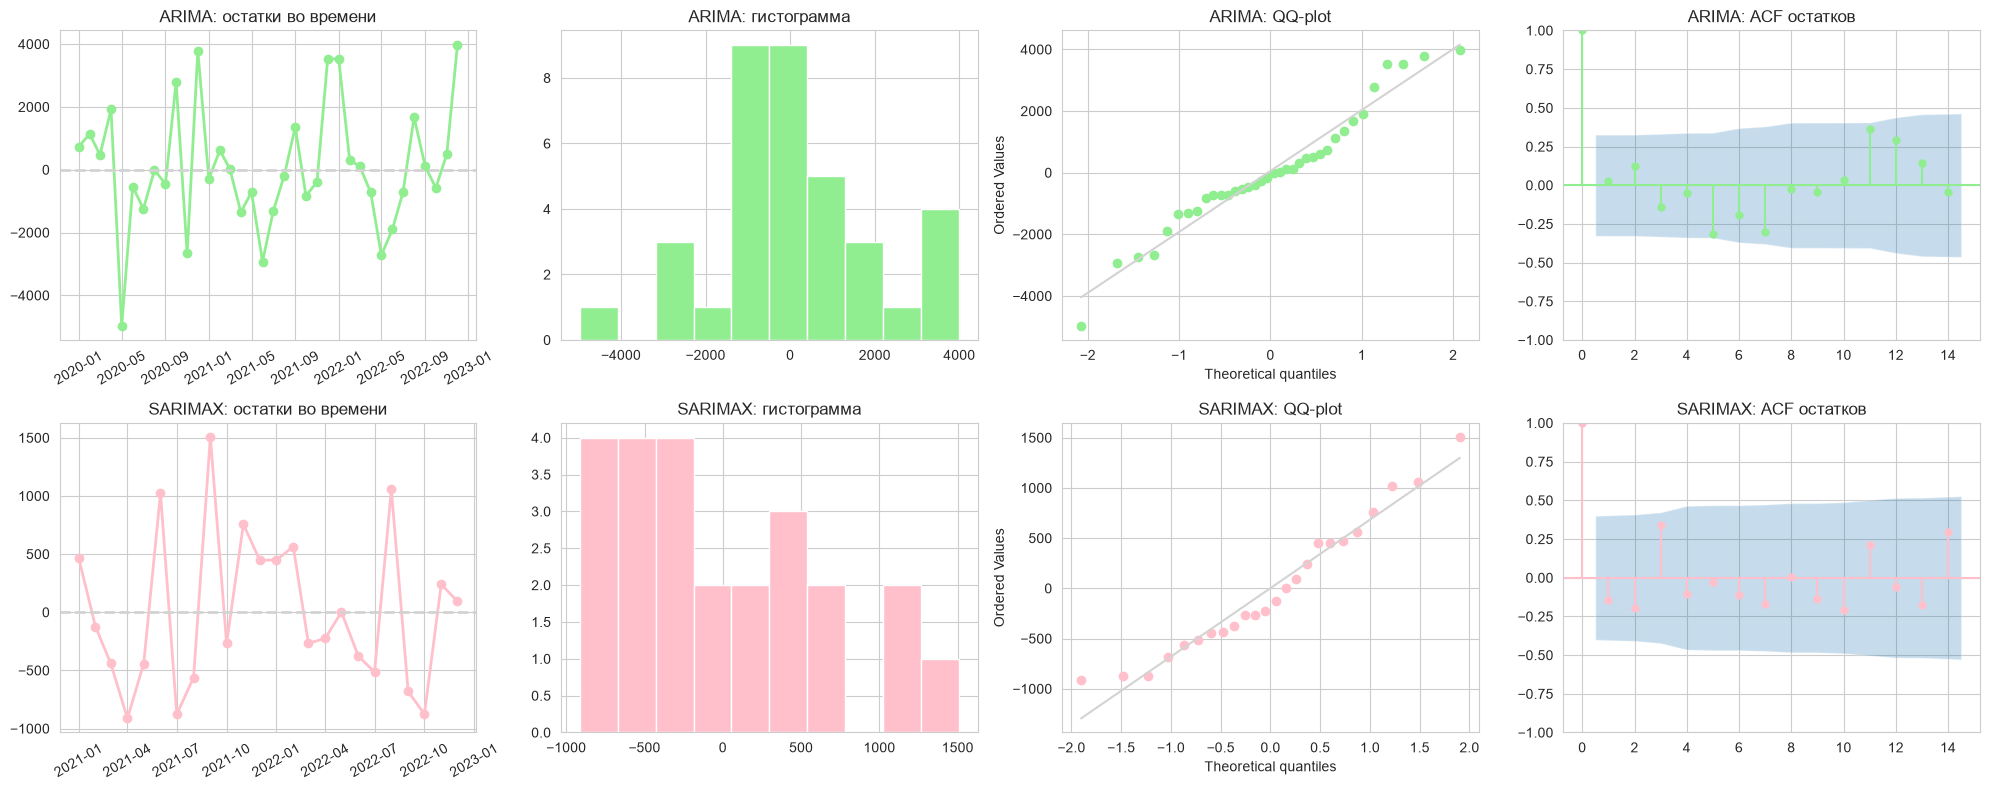

In [110]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

def get_resid(model):
    # Первые остатки выкидываем, пока модель разгоняется из-за разностей, это не настоящие ошибки
    # (у SARIMAX их 12, у ARIMA с d=1 один, с d=0 нет), а по размеру они почти как сами продажи и портят все тесты
    burn = model.model.loglikelihood_burn
    return model.resid.iloc[burn:]

resid_a = get_resid(arima_model)
resid_s = get_resid(sarimax_model)
print(f'Остатков: ARIMA {len(resid_a)}, SARIMAX {len(resid_s)}')

# Графики остатков: во времени, гистограмма, QQ-plot и ACF (до лага 14, чтобы был виден сезонный лаг 12)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for i, (name, resid) in enumerate([('ARIMA', resid_a), ('SARIMAX', resid_s)]):
    r = np.asarray(resid).ravel()
    c = colors[name]

    axes[i, 0].plot(resid.index, r, marker='o', color=c, linewidth=2)
    axes[i, 0].axhline(0, color='lightgray', linestyle='--', linewidth=2)
    axes[i, 0].set_title(f'{name}: остатки во времени')
    axes[i, 0].tick_params(axis='x', rotation=30)

    axes[i, 1].hist(r, bins=10, color=c, edgecolor='white')
    axes[i, 1].set_title(f'{name}: гистограмма')

    stats.probplot(r, plot=axes[i, 2])
    axes[i, 2].set_title(f'{name}: QQ-plot')
    dots, line = axes[i, 2].get_lines()[0], axes[i, 2].get_lines()[1]
    dots.set_markerfacecolor(c); dots.set_markeredgecolor(c)
    line.set_color('lightgray')

    plot_acf(r, lags=14, ax=axes[i, 3], color=c, vlines_kwargs={'colors': c})
    axes[i, 3].set_title(f'{name}: ACF остатков')
plt.tight_layout(); plt.show()

In [111]:
# Тесты остатков. Во всех p-value: p > 0.05 значит, что проблема не найдена
def residual_tests(resid):
    r = np.asarray(resid).ravel()
    # Проверяем, не меняется ли дисперсия остатков со временем
    t = sm.add_constant(np.arange(len(r)))
    lb = acorr_ljungbox(r, lags=[6, 12], return_df=True)
    return {
        'Среднее остатков': r.mean(),
        'Шапиро-Уилк p (нормальность)': shapiro(r)[1],
        'Льюнг-Бокс p, лаг 6 (автокорр.)': lb['lb_pvalue'].iloc[0],
        'Льюнг-Бокс p, лаг 12 (автокорр.)': lb['lb_pvalue'].iloc[1],
        'Дарбин-Уотсон (около 2 - ок)': durbin_watson(r),
        'Бройш-Паган p (гомоскед.)': het_breuschpagan(r, t)[1],
    }

resid_tests_df = pd.DataFrame({'ARIMA': residual_tests(resid_a),
                               'SARIMAX': residual_tests(resid_s)}).T.round(4)
resid_tests_df

,Среднее остатков,Шапиро-Уилк p (нормальность),"Льюнг-Бокс p, лаг 6 (автокорр.)","Льюнг-Бокс p, лаг 12 (автокорр.)",Дарбин-Уотсон (около 2 - ок),Бройш-Паган p (гомоскед.)
ARIMA,56.724,0.2236,0.2605,0.0198,1.8276,0.8778
SARIMAX,1.974,0.2768,0.4380,0.4542,2.2664,0.5267


Остатки (у SARIMAX 24 точки, первые 12 разгонных остатков выкинули, у ARIMA все 36):

- Нормальность. Шапиро-Уилк дает p = 0.28 у SARIMAX и 0.22 у ARIMA, оба больше 0.05, значит нормальность не отвергаем. На QQ-plot точки идут вдоль линии, на хвостах небольшие отклонения.
- Автокорреляция. у SARIMAX Льюнг-Бокс на лагах 6 и 12 дает p = 0.44 и 0.45, Дарбин-Уотсон 2.27, на ACF все столбики внутри доверительного интервала, значимой автокорреляции нет. У ARIMA на лаге 6 все нормально (p = 0.26), а вот на лаге 12 p = 0.02, то есть остается значимая автокорреляция на сезонном лаге. Это та самая годовая сезонность, которую ARIMA не умеет учитывать, и она согласуется с плохим прогнозом.
- Гомоскедастичность. Бройш-Паган (дисперсия против времени) дает p = 0.53 у SARIMAX и 0.88 у ARIMA, значит дисперсия со временем не меняется.
- Среднее остатков у SARIMAX почти 0 (около 2), у ARIMA около 57, на фоне разброса в тысячи это тоже мало.

У SARIMAX проблем по остаткам нет. А у ARIMA непосчитанная сезонность. Точек мало, и тесты на такой выборке слабые, поэтому решающими считаем метрики на тесте и AIC/BIC.

| Критерий | SARIMAX | ARIMA |
|---|---|---|
| MSE на тесте | 0.82 млн | 4.73 млн |
| R^2 на тесте | 0.82 | -0.02 |
| AIC / BIC (по общим точкам) | 375 / 382 | 416 / 419 |
| Нормальность остатков (Шапиро-Уилк) | p = 0.28, нормальные | p = 0.22, нормальные |
| Автокорреляция (Льюнг-Бокс, лаг 6) | p = 0.44, нет | p = 0.26, нет |
| Автокорреляция (Льюнг-Бокс, лаг 12) | p = 0.45, нет | p = 0.02, есть (сезонность) |
| Гомоскедастичность (Бройш-Паган) | p = 0.53, есть | p = 0.88, есть |

Лучше SARIMAX(0, 0, 1)(0, 1, 1, 12) с константой и экзогенными `Promotion` и `HolidayMonth`. Она лучше по MSE, R^2, AIC и BIC, остатки у нее в порядке, а у ARIMA в остатках осталась годовая сезонность. Но преимущество над сезонным наивом держится на двух промо-месяцах теста.

---
# 2.4. Документирование и интерпретация

1. EDA показал сильную годовую сезонность (s = 12) и слабый восходящий тренд. Ряд стационарен без разности, а сезонная разность `D = 1` нужна из-за сильной сезонности.
2. Аддитивная и мультипликативная дают почти одинаковый результат, поэтому ряд ближе к аддитивной модели, а STL (с robust) выделила сезонность лучше всех (0.84). FFT подтверждает период 12 месяцев, вейвлет Морле тоже, но по скалограмме нельзя уверенно сказать, что сезонность меняется со временем.
3. Порядки подобраны grid search по AIC, вырожденные решения отброшены. Получились ARIMA(1, 0, 0) с константой (случайное блуждание по AIC шло первым, но это просто последнее значение, поэтому взяли `d = 0`) и SARIMAX(0, 0, 1)(0, 1, 1, 12) с константой, `Promotion` и `HolidayMonth`. Максимальный горизонт с приемлемым качеством (R² не ниже 0.7) равен 21 месяцу, на 24 месяцах модель уже не справляется.
4. Пр метрикам SARIMAX лучше, чем ARIMA, по всем критериям: MSE 0.82 млн против 4.73 млн, R^2 0.82 против -0.02, AIC 375 против 416, BIC 382 против 419. Остатки SARIMAX прошли тесты на нормальность, автокорреляцию и гомоскедастичность, а у ARIMA тест Льюнга-Бокса на лаге 12 нашел оставшуюся сезонность (на такой короткой выборке тесты слабые).
5. Я бы предпочел SARIMAX для прогноза продаж на горизонте до года. Признак `HolidayMonth` модель отдельно не оценивает (он совпадает с декабрем, и сезонная разность его убирает), но декабрьский пик прогноз все равно воспроизводит, хотя и недооценивает.